# 🔍 Arabic Fake News Detection — Full EDA Notebook
**Graduation Project 2026**

Datasets: **VERA** · **AraFacts** · **Saheeh Masr**  
Base Encoder: `UBC-NLP/MARBERTv2`

---
### Notebook Structure
1. Setup & Imports
2. Data Loading & Schema Inspection
3. Label Analysis (Distribution, Imbalance, AraFacts Mapping)
4. Text Length Statistics
5. Vocabulary Size & OOV Analysis
6. Lexical Diversity
7. Frequent Words & N-gram Analysis
8. Duplicate & Near-Duplicate Detection
9. Noise Detection & Label Quality
10. Named Entity Distribution (VERA pre-extracted)
11. Social Media Features (VERA-specific)
12. Topic Modeling (BERTopic)
13. MARBERTv2 Embedding Space Visualization (UMAP / t-SNE)
14. Domain Shift Quantification (A-distance, MMD)
15. Cross-Dataset Similarity Summary
16. Overfitting & Negative Transfer Diagnostics

In [1]:
!pip install numpy==1.26.4 --force-reinstall -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which i

In [2]:
!pip install umap-learn==0.5.5 hdbscan==0.8.33 bertopic==0.16.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 36.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.1/154.1 kB 10.0 MB/s eta 0:00:00


In [1]:
from bertopic import BERTopic
from umap import UMAP
import pandas as pd
import numpy as np

print("All imports OK")

All imports OK


---
## 1. Setup & Imports

In [1]:
# Install all required packages
!pip install -q transformers datasets umap-learn bertopic camel-tools pyarabic \
    datasketch sentence-transformers scikit-learn matplotlib seaborn plotly \
    wordcloud arabic_reshaper python-bidi openpyxl tqdm

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 31.3 MB/s eta 0:00:00
   ━━━━━━

In [1]:
!pip install -U numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 27.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
camel-tools 1.5.7 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import re
import os
from collections import Counter
from tqdm.auto import tqdm
tqdm.pandas()
warnings.filterwarnings('ignore')

# Arabic text display helpers
import arabic_reshaper
from bidi.algorithm import get_display

def ar(text):
    """Reshape Arabic text for matplotlib display."""
    return get_display(arabic_reshaper.reshape(str(text)))

# Matplotlib Arabic font
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Color palette used throughout
COLORS = {
    'VERA':       '#E63946',   # red
    'AraFacts':   '#457B9D',   # blue
    'Saheeh':     '#2A9D8F',   # teal
    'fake':       '#E76F51',   # orange
    'real':       '#264653',   # dark
}

print('✅ Imports complete')

✅ Imports complete


---
## 2. Data Loading & Schema Inspection

**Update the three paths below to point to your files.**

In [2]:
# ── EDIT THESE PATHS ──────────────────────────────────────────────
VERA_PATH     = 'VERAARAB_dataset.xlsx'          # excel
ARAFACTS_PATH = 'AraFacts.csv'     # csv
SAHEEH_PATH   = 'saheeh_masr_claims.csv'  # CSV
# ──────────────────────────────────────────────────────────────────

vera    = pd.read_excel(VERA_PATH)
arafacts = pd.read_csv(ARAFACTS_PATH, low_memory=False)
saheeh  = pd.read_csv(SAHEEH_PATH, low_memory=False)

print(f'VERA      : {vera.shape}')
print(f'AraFacts  : {arafacts.shape}')
print(f'Saheeh Masr: {saheeh.shape}')

VERA      : (20084, 78)
AraFacts  : (6222, 13)
Saheeh Masr: (3019, 7)


In [3]:
print('=== VERA columns ===')
print(vera.dtypes)
print('\n=== AraFacts columns ===')
print(arafacts.dtypes)
print('\n=== Saheeh Masr columns ===')
print(saheeh.dtypes)

=== VERA columns ===
tweet_id                int64
possibly_sensitive       bool
retweet_count           int64
reply_count             int64
like_count              int64
                        ...  
user_year               int64
user_acc_months_age     int64
tweet_months_age        int64
domain                 object
domain_label           object
Length: 78, dtype: object

=== AraFacts columns ===
ClaimID                object
claim                  object
description            object
source                 object
date                   object
source_label           object
normalized_label       object
source_category        object
normalized_category    object
source_url             object
claim_urls             object
evidence_urls          object
claim_type              int64
dtype: object

=== Saheeh Masr columns ===
node_id         int64
claim          object
verdict          bool
description    object
date           object
url            object
source         object
dtype: obj

In [4]:
# Preview first rows of each
print('--- VERA sample ---')
display(vera[['tweet_id', 'text_arabic', 'label']].head(3))

print('--- AraFacts sample ---')
display(arafacts[['ClaimID', 'claim', 'source_label', 'normalized_label']].head(3))

print('--- Saheeh Masr sample ---')
display(saheeh[['node_id', 'claim', 'verdict']].head(3))

--- VERA sample ---


,tweet_id,text_arabic,label
0,1697950090223026335,البحرية الجزائرية تقتل مغاربة أمام أعين الناس...,1
1,1697935446666510767,مداهمة قوات البياري و الصاعقة لأخط.ـر أحياء وه...,1
2,1620816468328972288,هل فعلا هذه هي تميمة كأس العالم للأندية المقا...,1


--- AraFacts sample ---


,ClaimID,claim,source_label,normalized_label
0,MIS_2952,الشركة المالكة للعبة ببجي (PUBG) أعلنت يوم 26 ...,زائف,False
1,MIS_2951,"تصريح لمبابي يقول فيه ""أريد أن أصبح مثل رونالد...",مضلل,Partly-false
2,FAT_1503,وفاة الفنان يوسف شعبان,correct,True


--- Saheeh Masr sample ---


,node_id,claim,verdict
0,155,تراجعت إيرادات القناة 6 مليار دولار في السنة ا...,True
1,157,هي إيه السياحة في قطر؟ عندك تاريخ؟ عندك شواطئ ...,False
2,158,في عهد السيسي عندنا 3602 مسجد ما بين بناء وتجد...,True


In [4]:
# Standardise: add unified columns 'text' and 'binary_label' to each dataframe
# VERA: text_arabic (Arabic text), label (0/1 already)
vera['text']         = vera['text_arabic'].astype(str)
vera['binary_label'] = vera['label'].astype(int)   # already 0/1
vera['dataset']      = 'VERA'

# Saheeh Masr: claim, verdict (True/False)
saheeh['text']         = saheeh['claim'].astype(str)
saheeh['binary_label'] = (~saheeh['verdict'].astype(bool)).astype(int)  # True=real=0, False=fake=1
saheeh['dataset']      = 'Saheeh'

# AraFacts: claim, source_label — needs mapping
# We will do the mapping in Section 3 and store it back here
arafacts['text']    = arafacts['claim'].astype(str)
arafacts['dataset'] = 'AraFacts'

print('✅ Unified text/label columns created')

✅ Unified text/label columns created


---
## 3. Label Analysis

**Why:** Class imbalance directly distorts accuracy. A model predicting the majority class always can reach deceptively high accuracy. Also, AraFacts has 35+ raw label variants that need a principled binary mapping — documenting this is critical for your thesis.

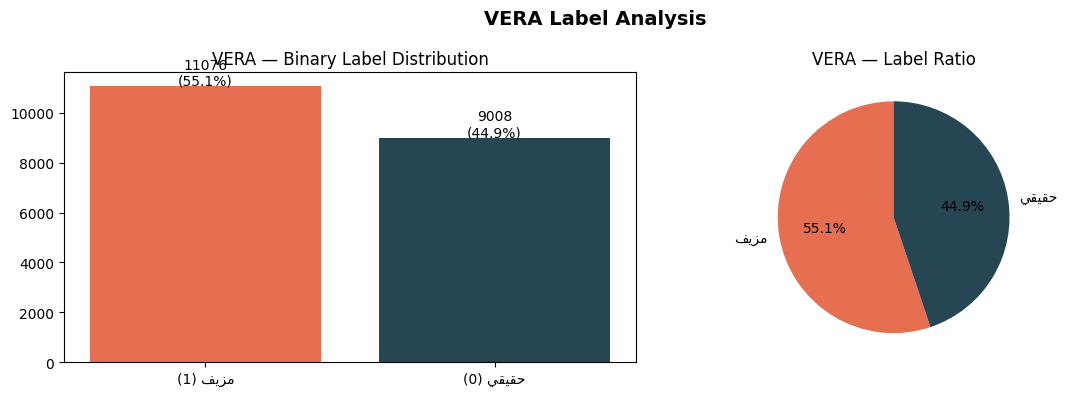

Imbalance ratio (majority/minority): 1.23
⚠️ PROBLEM if ratio > 3: model may learn majority-class bias


In [14]:
# ── 3.1 VERA label distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vera_counts = vera['binary_label'].value_counts()
axes[0].bar([ar('مزيف (1)'), ar('حقيقي (0)')],
            [vera_counts.get(1, 0), vera_counts.get(0, 0)],
            color=[COLORS['fake'], COLORS['real']])
axes[0].set_title('VERA — Binary Label Distribution')
for i, v in enumerate([vera_counts.get(1,0), vera_counts.get(0,0)]):
    axes[0].text(i, v + 50, f'{v}\n({v/len(vera)*100:.1f}%)', ha='center')

axes[1].pie([vera_counts.get(1, 0), vera_counts.get(0, 0)],
            labels=[ar('مزيف'), ar('حقيقي')],
            colors=[COLORS['fake'], COLORS['real']],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('VERA — Label Ratio')

plt.suptitle('VERA Label Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vera_labels.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = vera_counts.max() / vera_counts.min()
print(f'Imbalance ratio (majority/minority): {imbalance_ratio:.2f}')
print('⚠️ PROBLEM if ratio > 3: model may learn majority-class bias')

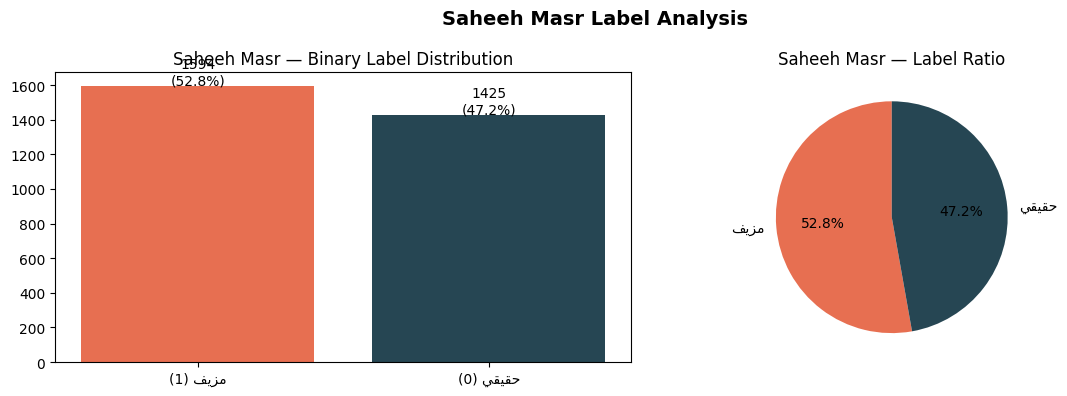

Imbalance ratio: 1.12

VERA majority class    : fake
Saheeh Masr majority class: fake
✅ Same majority class direction


In [15]:
# ── 3.2 Saheeh Masr label distribution ───────────────────────────
saheeh_counts = saheeh['binary_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([ar('مزيف (1)'), ar('حقيقي (0)')],
            [saheeh_counts.get(1, 0), saheeh_counts.get(0, 0)],
            color=[COLORS['fake'], COLORS['real']])
axes[0].set_title('Saheeh Masr — Binary Label Distribution')
for i, v in enumerate([saheeh_counts.get(1,0), saheeh_counts.get(0,0)]):
    axes[0].text(i, v + 10, f'{v}\n({v/len(saheeh)*100:.1f}%)', ha='center')

axes[1].pie([saheeh_counts.get(1, 0), saheeh_counts.get(0, 0)],
            labels=[ar('مزيف'), ar('حقيقي')],
            colors=[COLORS['fake'], COLORS['real']],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Saheeh Masr — Label Ratio')

plt.suptitle('Saheeh Masr Label Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('saheeh_labels.png', dpi=150, bbox_inches='tight')
plt.show()

sm_ratio = saheeh_counts.max() / saheeh_counts.min()
print(f'Imbalance ratio: {sm_ratio:.2f}')

# KEY DIAGNOSTIC: are majority classes the same direction across datasets?
vera_majority   = 'fake' if vera['binary_label'].mean() > 0.5 else 'real'
saheeh_majority = 'fake' if saheeh['binary_label'].mean() > 0.5 else 'real'
print(f'\nVERA majority class    : {vera_majority}')
print(f'Saheeh Masr majority class: {saheeh_majority}')
if vera_majority != saheeh_majority:
    print('🚨 OPPOSITE MAJORITY CLASSES — this alone explains part of the 42.9% F1 failure!')
else:
    print('✅ Same majority class direction')

AraFacts source_label counts:
source_label
مضلل                    1481
زائف                    1031
خطأ                      882
fake                     749
NaN                      707
misleading-title         420
partially-fake           160
 مضلل                    122
صحيح                      85
correct                   70
إثارة                     63
مركب                      62
 زائف                     61
misleading                53
ساخر                      52
غير صحيح                  44
sarcastic                 35
انتقائي                   30
مشكوك فيه                 26
صحيح جزئياً               23
خرافة                     19
missing-content            8
مجتزأ                      6
opinion                    6
 إثارة                     6
 صحيح                      4
 ساخر                      3
مركّبة                     3
deceptive                  2
مركّب                      2
 انتقائي                   2
احتيال                     1
معلومات علميّة ناقصة       1


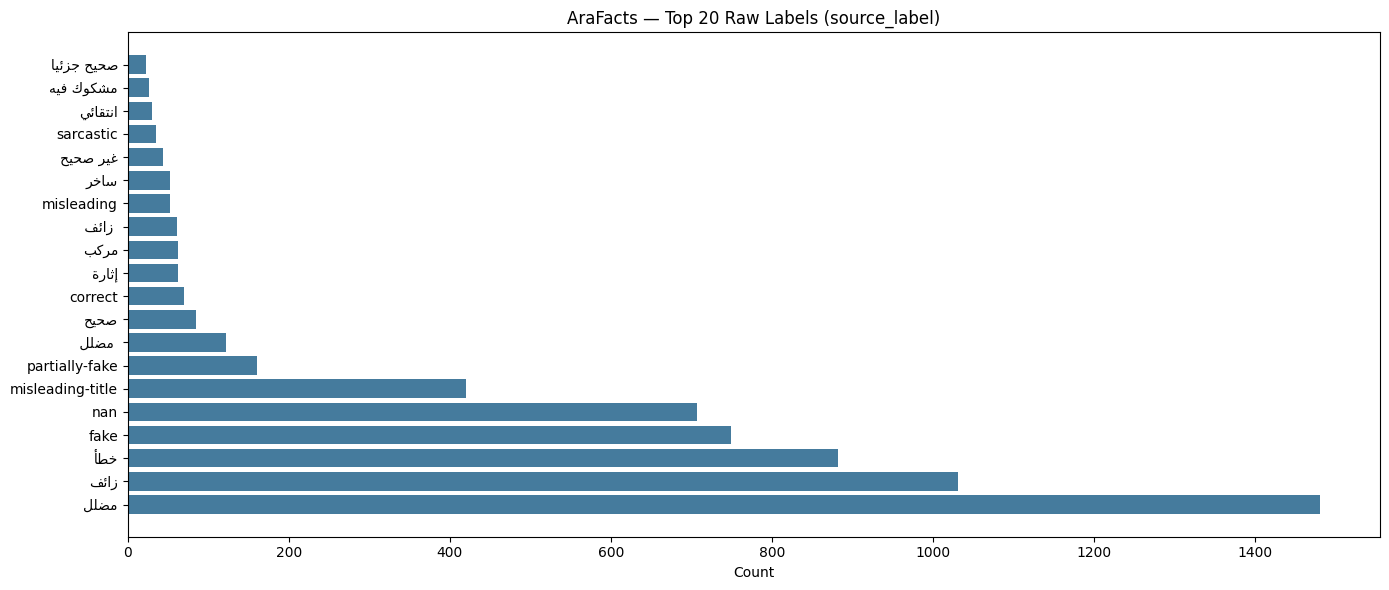

In [16]:
# ── 3.3 AraFacts — Raw label distribution (all 35+ variants) ─────
raw_counts = arafacts['source_label'].value_counts(dropna=False)
print('AraFacts source_label counts:')
print(raw_counts.to_string())

# Plot top-20 raw labels
top20 = raw_counts.head(20)
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh([ar(str(l)) for l in top20.index], top20.values, color=COLORS['AraFacts'])
ax.set_xlabel('Count')
ax.set_title('AraFacts — Top 20 Raw Labels (source_label)')
plt.tight_layout()
plt.savefig('arafacts_raw_labels.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── 3.4 AraFacts — Principled Binary Mapping ─────────────────────
# REAL (0): صحيح, correct, حقيقة, صحيح جزئياً* (debatable), opinion*
# FAKE (1): everything else
# * Mark ambiguous ones and report their count separately

REAL_LABELS = {
    'correct', 'صحيح', ' صحيح ', 'حقيقة'
}
AMBIGUOUS_LABELS = {
    'صحيح جزئياً', 'opinion', 'مشكوك فيه', 'sarcastic', 'ساخر', ' ساخر ',
    'partially-fake', 'انتقائي', ' انتقائي ', 'مجتزأ'
}

def map_arafacts_label(raw):
    if pd.isna(raw):
        return np.nan
    raw = str(raw).strip()
    if raw in REAL_LABELS:
        return 0
    elif raw in AMBIGUOUS_LABELS:
        return 2  # ambiguous — flagged separately
    else:
        return 1

arafacts['binary_label_raw'] = arafacts['source_label'].apply(map_arafacts_label)

# Report ambiguous
n_ambiguous = (arafacts['binary_label_raw'] == 2).sum()
n_nan       = arafacts['binary_label_raw'].isna().sum()
print(f'Ambiguous labels : {n_ambiguous} ({n_ambiguous/len(arafacts)*100:.1f}%)')
print(f'NaN labels       : {n_nan}')
print(f'\n⚠️  These {n_ambiguous} ambiguous samples are label noise candidates.')
print('Decision: map ambiguous → FAKE (1) conservatively, or drop them.')

# For main analysis: map ambiguous → 1 (fake) as conservative choice
arafacts['binary_label'] = arafacts['binary_label_raw'].replace(2, 1).fillna(1).astype(int)

af_counts = arafacts['binary_label'].value_counts()
print(f'\nAraFacts binary: Fake={af_counts.get(1,0)}, Real={af_counts.get(0,0)}')
af_ratio = af_counts.max() / af_counts.min()
print(f'Imbalance ratio: {af_ratio:.2f}')

Ambiguous labels : 343 (5.5%)
NaN labels       : 707

⚠️  These 343 ambiguous samples are label noise candidates.
Decision: map ambiguous → FAKE (1) conservatively, or drop them.

AraFacts binary: Fake=6062, Real=160
Imbalance ratio: 37.89


=== Cross-Dataset Label Summary ===


,Dataset,Total,Fake (1),Real (0),Fake%,Real%,Imbalance Ratio
0,VERA,20084,11076,9008,55.1,44.9,1.23
1,AraFacts,6222,6062,160,97.4,2.6,37.89
2,Saheeh Masr,3019,1594,1425,52.8,47.2,1.12


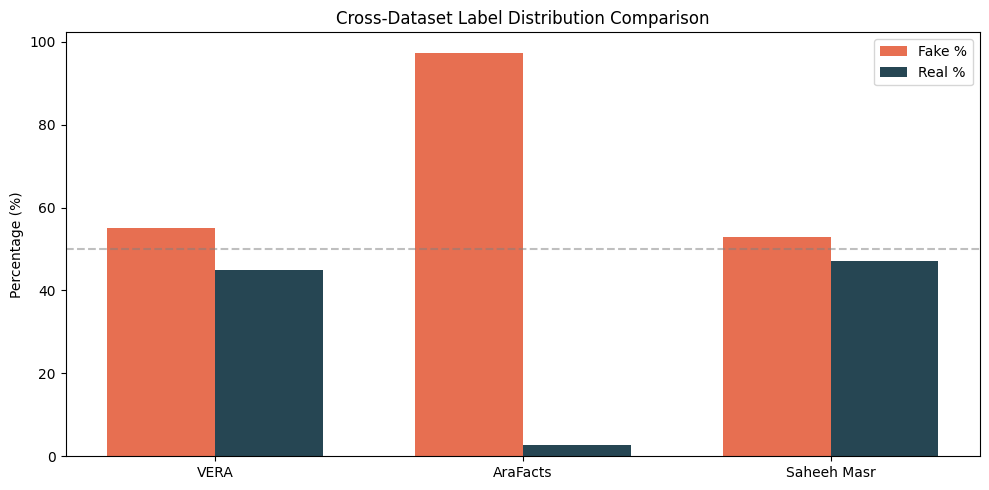

In [18]:
# ── 3.5 Cross-dataset label comparison ───────────────────────────
datasets_summary = pd.DataFrame({
    'Dataset'    : ['VERA', 'AraFacts', 'Saheeh Masr'],
    'Total'      : [len(vera), len(arafacts), len(saheeh)],
    'Fake (1)'   : [
        vera['binary_label'].sum(),
        arafacts['binary_label'].sum(),
        saheeh['binary_label'].sum()
    ],
    'Real (0)'   : [
        (vera['binary_label'] == 0).sum(),
        (arafacts['binary_label'] == 0).sum(),
        (saheeh['binary_label'] == 0).sum()
    ],
})
datasets_summary['Fake%'] = (datasets_summary['Fake (1)'] / datasets_summary['Total'] * 100).round(1)
datasets_summary['Real%'] = (datasets_summary['Real (0)'] / datasets_summary['Total'] * 100).round(1)
datasets_summary['Imbalance Ratio'] = (
    datasets_summary[['Fake (1)', 'Real (0)']].max(axis=1) /
    datasets_summary[['Fake (1)', 'Real (0)']].min(axis=1)
).round(2)

print('=== Cross-Dataset Label Summary ===')
display(datasets_summary)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, datasets_summary['Fake%'], w, label='Fake %', color=COLORS['fake'])
ax.bar(x + w/2, datasets_summary['Real%'], w, label='Real %', color=COLORS['real'])
ax.set_xticks(x)
ax.set_xticklabels(['VERA', 'AraFacts', 'Saheeh Masr'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Cross-Dataset Label Distribution Comparison')
ax.legend()
ax.axhline(50, color='grey', linestyle='--', alpha=0.5, label='50% baseline')
plt.tight_layout()
plt.savefig('label_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Text Length Statistics

**Why:** VERA is social media (short, noisy), Saheeh Masr is formal news (longer, denser). If the model learned 'short = fake' as a spurious shortcut from VERA, it will fail on Saheeh Masr where article length is independent of truthfulness. Also affects MARBERTv2's 512-token truncation.

In [19]:
from transformers import AutoTokenizer

print('Loading MARBERTv2 tokenizer...')
tokenizer = AutoTokenizer.from_pretrained('UBC-NLP/MARBERTv2')

def token_length(text):
    return len(tokenizer.encode(str(text), truncation=False, add_special_tokens=True))

print('Computing token lengths (this may take a few minutes)...')
vera['token_len']    = vera['text'].progress_apply(token_length)
arafacts['token_len'] = arafacts['text'].progress_apply(token_length)
saheeh['token_len']  = saheeh['text'].progress_apply(token_length)

# Also compute character and word lengths
for df in [vera, arafacts, saheeh]:
    df['char_len'] = df['text'].str.len()
    df['word_len'] = df['text'].str.split().str.len()

print('✅ Length features computed')

Loading MARBERTv2 tokenizer...
Computing token lengths (this may take a few minutes)...


  0%|          | 0/20084 [00:00<?, ?it/s]

  0%|          | 0/6222 [00:00<?, ?it/s]

  0%|          | 0/3019 [00:00<?, ?it/s]

✅ Length features computed


In [20]:
# Summary stats
def length_stats(df, name):
    stats = df['token_len'].describe(percentiles=[.05, .25, .5, .75, .95, .99])
    pct_over_512 = (df['token_len'] > 512).mean() * 100
    print(f'\n=== {name} — Token Length Stats ===')
    print(stats.round(1))
    print(f'% samples > 512 tokens (truncated by MARBERTv2): {pct_over_512:.1f}%')

length_stats(vera,     'VERA')
length_stats(arafacts, 'AraFacts')
length_stats(saheeh,   'Saheeh Masr')


=== VERA — Token Length Stats ===
count    20084.0
mean        25.6
std         14.3
min          2.0
5%           9.0
25%         15.0
50%         22.0
75%         33.0
95%         56.0
99%         63.0
max         87.0
Name: token_len, dtype: float64
% samples > 512 tokens (truncated by MARBERTv2): 0.0%

=== AraFacts — Token Length Stats ===
count    6222.0
mean       17.5
std        10.5
min         4.0
5%          7.0
25%        11.0
50%        15.0
75%        21.0
95%        35.0
99%        55.0
max       180.0
Name: token_len, dtype: float64
% samples > 512 tokens (truncated by MARBERTv2): 0.0%

=== Saheeh Masr — Token Length Stats ===
count    3019.0
mean       30.6
std        19.6
min         4.0
5%         11.0
25%        17.0
50%        26.0
75%        37.0
95%        67.0
99%        94.0
max       402.0
Name: token_len, dtype: float64
% samples > 512 tokens (truncated by MARBERTv2): 0.0%


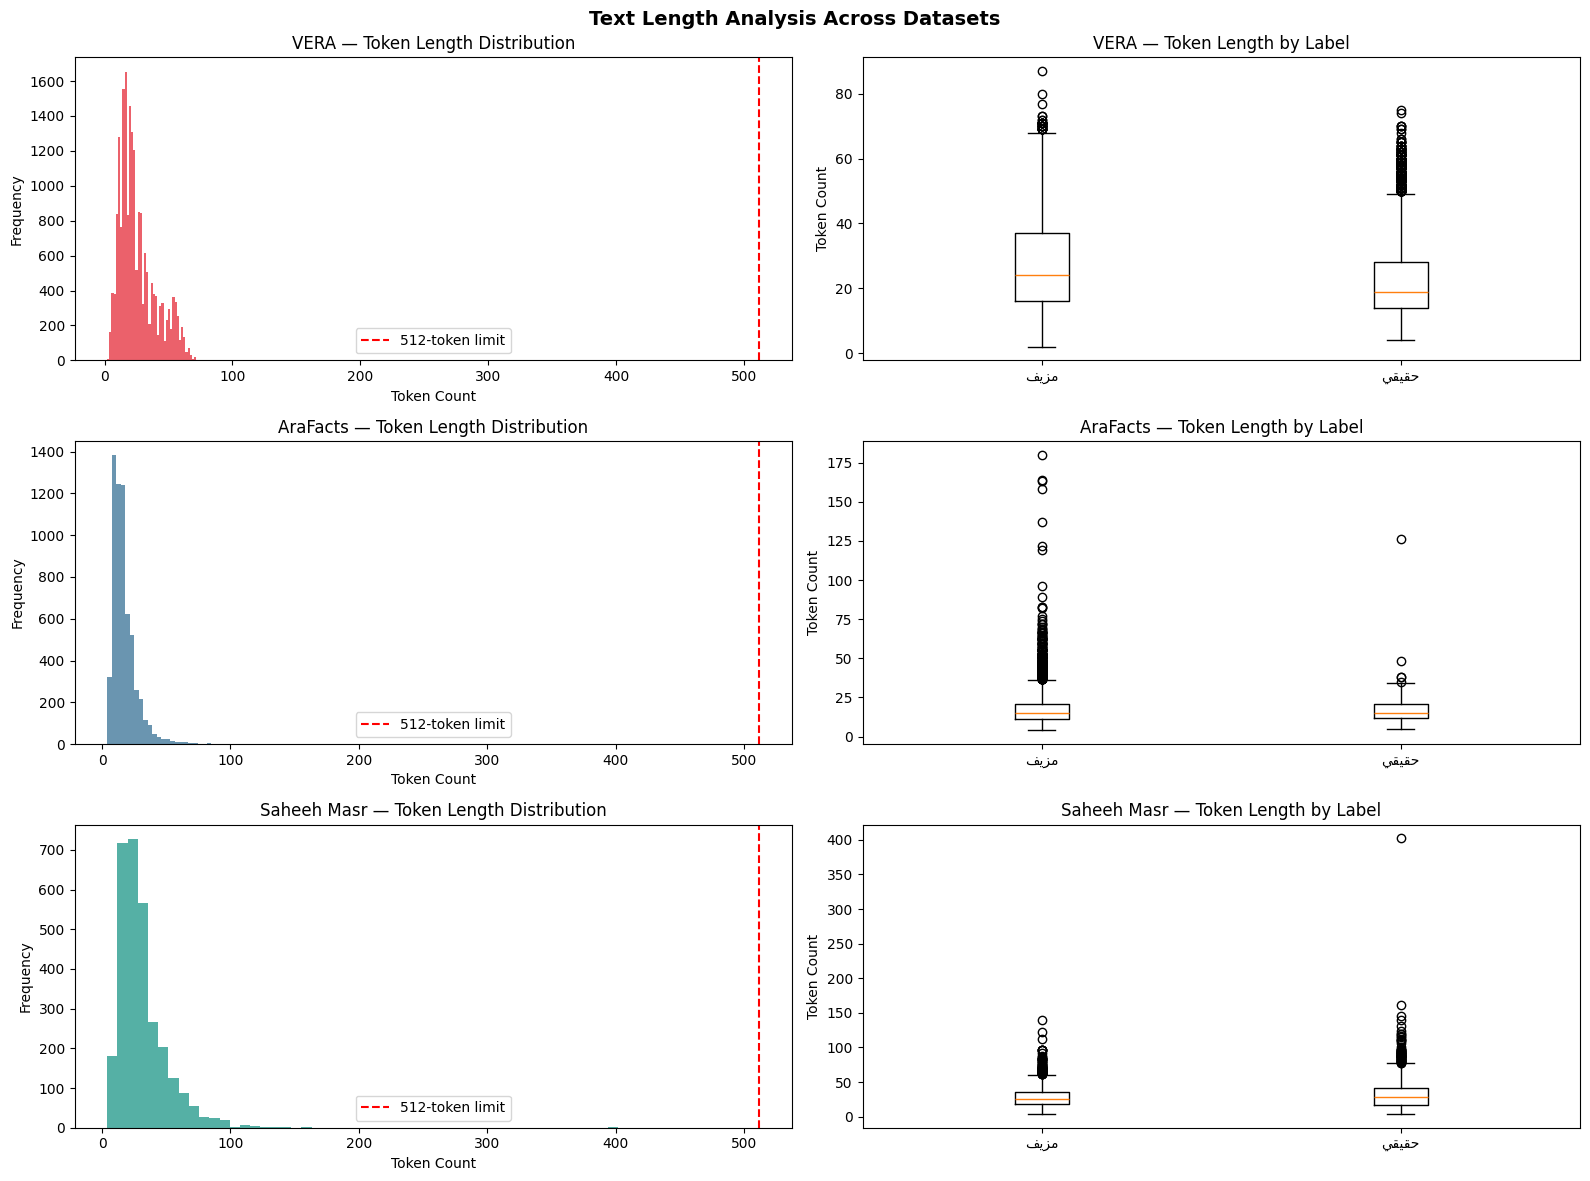


⚠️  KEY CHECK: If fake/real boxes differ significantly within VERA but not Saheeh,
   the model may be exploiting length as a spurious feature.


In [21]:
# Distribution plots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i, (df, name, color) in enumerate([
    (vera,     'VERA',       COLORS['VERA']),
    (arafacts, 'AraFacts',   COLORS['AraFacts']),
    (saheeh,   'Saheeh Masr', COLORS['Saheeh']),
]):
    # Token length histogram
    ax = axes[i][0]
    ax.hist(df['token_len'].clip(upper=600), bins=50, color=color, alpha=0.8)
    ax.axvline(512, color='red', linestyle='--', label='512-token limit')
    ax.set_title(f'{name} — Token Length Distribution')
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Frequency')
    ax.legend()

    # Per-class box plot
    ax2 = axes[i][1]
    data_fake = df[df['binary_label'] == 1]['token_len']
    data_real = df[df['binary_label'] == 0]['token_len']
    ax2.boxplot([data_fake, data_real], labels=[ar('مزيف'), ar('حقيقي')])
    ax2.set_title(f'{name} — Token Length by Label')
    ax2.set_ylabel('Token Count')

plt.suptitle('Text Length Analysis Across Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  KEY CHECK: If fake/real boxes differ significantly within VERA but not Saheeh,')
print('   the model may be exploiting length as a spurious feature.')

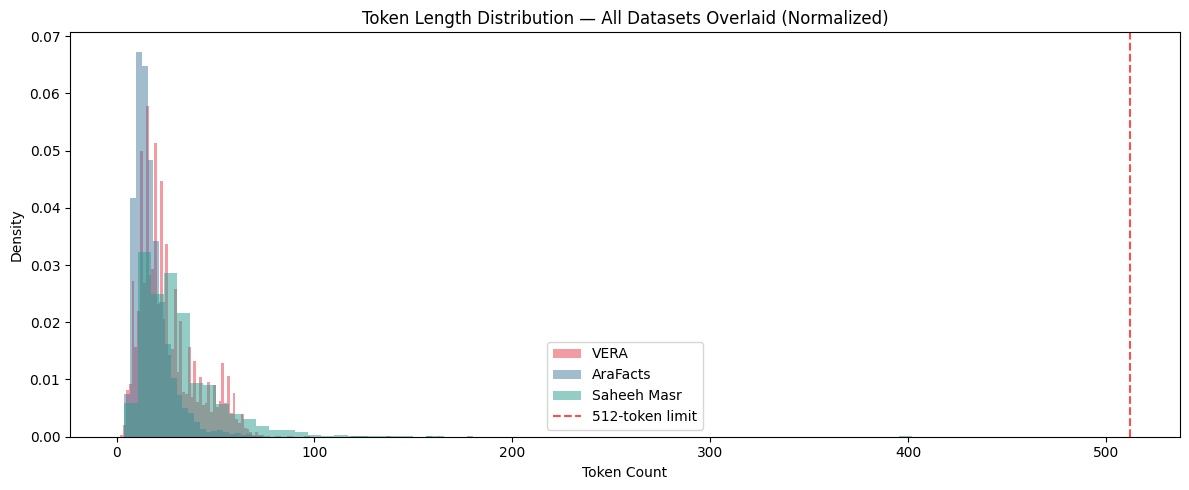

In [22]:
# Cross-dataset overlap visualization
fig, ax = plt.subplots(figsize=(12, 5))
for df, name, color in [
    (vera,     'VERA',        COLORS['VERA']),
    (arafacts, 'AraFacts',    COLORS['AraFacts']),
    (saheeh,   'Saheeh Masr', COLORS['Saheeh']),
]:
    ax.hist(df['token_len'].clip(upper=600), bins=60, alpha=0.5,
            label=name, color=color, density=True)
ax.axvline(512, color='red', linestyle='--', alpha=0.7, label='512-token limit')
ax.set_title('Token Length Distribution — All Datasets Overlaid (Normalized)')
ax.set_xlabel('Token Count')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('length_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Vocabulary Size & OOV Analysis

**Why:** If Saheeh Masr uses vocabulary that never appears in VERA, the model's representations for those words come purely from MARBERTv2 pretraining with no task-specific signal. High OOV rates confirm vocabulary mismatch as a driver of generalization failure.

In [23]:
import pyarabic.araby as araby

def normalize_arabic(text):
    """Light normalization: remove diacritics, normalize alef/teh marbuta."""
    text = str(text)
    text = araby.strip_tashkeel(text)     # remove diacritics
    text = araby.normalize_ligature(text) # normalize lam-alef
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)  # keep only Arabic
    return text.strip()

def build_vocab(texts):
    """Word-level vocabulary from a list of texts."""
    vocab = Counter()
    for t in texts:
        tokens = normalize_arabic(t).split()
        vocab.update(tokens)
    return vocab

print('Building vocabularies...')
vera_vocab     = build_vocab(vera['text'])
arafacts_vocab = build_vocab(arafacts['text'])
saheeh_vocab   = build_vocab(saheeh['text'])

print(f'VERA      vocabulary size: {len(vera_vocab):,} unique tokens')
print(f'AraFacts  vocabulary size: {len(arafacts_vocab):,} unique tokens')
print(f'Saheeh    vocabulary size: {len(saheeh_vocab):,} unique tokens')

Building vocabularies...
VERA      vocabulary size: 38,823 unique tokens
AraFacts  vocabulary size: 20,793 unique tokens
Saheeh    vocabulary size: 16,228 unique tokens


In [24]:
# OOV: tokens in Saheeh Masr that do NOT appear in the training sets
vera_token_set     = set(vera_vocab.keys())
arafacts_token_set = set(arafacts_vocab.keys())
saheeh_token_set   = set(saheeh_vocab.keys())

# Compute by frequency to weight by actual occurrence
def weighted_oov(test_vocab, train_vocab_set):
    oov_count  = sum(v for k, v in test_vocab.items() if k not in train_vocab_set)
    total_count = sum(test_vocab.values())
    oov_types  = {k for k in test_vocab if k not in train_vocab_set}
    return oov_count / total_count * 100, len(oov_types) / len(test_vocab) * 100

oov_vera_sm_tok,    oov_vera_sm_typ    = weighted_oov(saheeh_vocab, vera_token_set)
oov_af_sm_tok,      oov_af_sm_typ      = weighted_oov(saheeh_vocab, arafacts_token_set)
oov_both_tok,       oov_both_typ       = weighted_oov(saheeh_vocab, vera_token_set | arafacts_token_set)
oov_marbert_tok,    oov_marbert_typ    = weighted_oov(saheeh_vocab,
    set(tokenizer.vocab.keys()))  # Against MARBERTv2 vocab

print('=== OOV Rates for Saheeh Masr tokens ===')
print(f'  vs VERA only         — Token OOV: {oov_vera_sm_tok:.1f}%  |  Type OOV: {oov_vera_sm_typ:.1f}%')
print(f'  vs AraFacts only     — Token OOV: {oov_af_sm_tok:.1f}%   |  Type OOV: {oov_af_sm_typ:.1f}%')
print(f'  vs VERA + AraFacts   — Token OOV: {oov_both_tok:.1f}%   |  Type OOV: {oov_both_typ:.1f}%')
print(f'  vs MARBERTv2 vocab   — Token OOV: {oov_marbert_tok:.1f}%  |  Type OOV: {oov_marbert_typ:.1f}%')
print()
print('⚠️  Type OOV > 30% = severe vocabulary mismatch')
print('⚠️  Token OOV > 15% = substantial fraction of test text unseen during training')

=== OOV Rates for Saheeh Masr tokens ===
  vs VERA only         — Token OOV: 20.3%  |  Type OOV: 52.3%
  vs AraFacts only     — Token OOV: 28.1%   |  Type OOV: 61.2%
  vs VERA + AraFacts   — Token OOV: 16.2%   |  Type OOV: 44.5%
  vs MARBERTv2 vocab   — Token OOV: 26.3%  |  Type OOV: 45.3%

⚠️  Type OOV > 30% = severe vocabulary mismatch
⚠️  Token OOV > 15% = substantial fraction of test text unseen during training


In [25]:
# Top OOV tokens in Saheeh Masr (vs VERA)
oov_tokens = {k: v for k, v in saheeh_vocab.items() if k not in vera_token_set}
top_oov = sorted(oov_tokens.items(), key=lambda x: -x[1])[:30]

print('Top 30 OOV tokens in Saheeh Masr (not in VERA), by frequency:')
for tok, cnt in top_oov:
    print(f'  {tok:20s}: {cnt}')

print('\n💡 If these are topic-specific terms (Egyptian politics, government, economy)')
print('   → confirms TOPIC mismatch, not just dialect mismatch')

Top 30 OOV tokens in Saheeh Masr (not in VERA), by frequency:
  نجيب                : 174
  زراعية              : 168
  ساويرس              : 168
  صادراتنا            : 164
  معظمها              : 164
  متحلقين             : 128
  يرتقون              : 128
  السويس              : 120
  رايحة               : 106
  نفقاتك              : 105
  محسب                : 104
  الاستدانة           : 77
  محيي                : 75
  إيرادات             : 63
  مازلنا              : 49
  الأرخص              : 49
  واستصلاح            : 48
  وتويتر،             : 34
  رسايل               : 32
  جنيه،               : 22
  الناتج              : 18
  بنتكلم              : 17
  الموازنة            : 17
  فاتت                : 14
  الفرد               : 14
  الحديد              : 14
  ثلث                 : 14
  أسئلة               : 13
  جه                  : 13
  رايتس               : 12

💡 If these are topic-specific terms (Egyptian politics, government, economy)
   → confirms TOPIC mismatch, not just 

---
## 6. Lexical Diversity

**Why:** Social media (VERA) has low lexical diversity — the same slang and dialect markers repeat. Formal news (Saheeh Masr) is richer. A model trained on repetitive low-diversity text may underweight rare but informative tokens at test time.

In [26]:
def mattr(tokens, window=100):
    """Moving-Average TTR — more stable than TTR for varying length texts."""
    if len(tokens) < window:
        return len(set(tokens)) / len(tokens) if tokens else 0
    scores = []
    for i in range(0, len(tokens) - window + 1, window // 2):
        w = tokens[i:i+window]
        scores.append(len(set(w)) / len(w))
    return np.mean(scores)

def compute_lexical_diversity(text):
    tokens = normalize_arabic(text).split()
    if not tokens:
        return pd.Series({'ttr': np.nan, 'mattr': np.nan, 'hapax': np.nan})
    freq = Counter(tokens)
    hapax = sum(1 for v in freq.values() if v == 1) / len(freq)
    ttr   = len(freq) / len(tokens)
    mat   = mattr(tokens)
    return pd.Series({'ttr': ttr, 'mattr': mat, 'hapax': hapax})

print('Computing lexical diversity (may take a moment)...')
vera_lex     = vera['text'].progress_apply(compute_lexical_diversity)
arafacts_lex = arafacts['text'].progress_apply(compute_lexical_diversity)
saheeh_lex   = saheeh['text'].progress_apply(compute_lexical_diversity)

print('\n=== MATTR (lexical richness, higher = more diverse) ===')
for lex, name in [(vera_lex,'VERA'),(arafacts_lex,'AraFacts'),(saheeh_lex,'Saheeh Masr')]:
    print(f'{name:12s}: mean={lex["mattr"].mean():.3f}  std={lex["mattr"].std():.3f}')

Computing lexical diversity (may take a moment)...


  0%|          | 0/20084 [00:00<?, ?it/s]

  0%|          | 0/6222 [00:00<?, ?it/s]

  0%|          | 0/3019 [00:00<?, ?it/s]


=== MATTR (lexical richness, higher = more diverse) ===
VERA        : mean=0.958  std=0.060
AraFacts    : mean=0.983  std=0.041
Saheeh Masr : mean=0.948  std=0.063


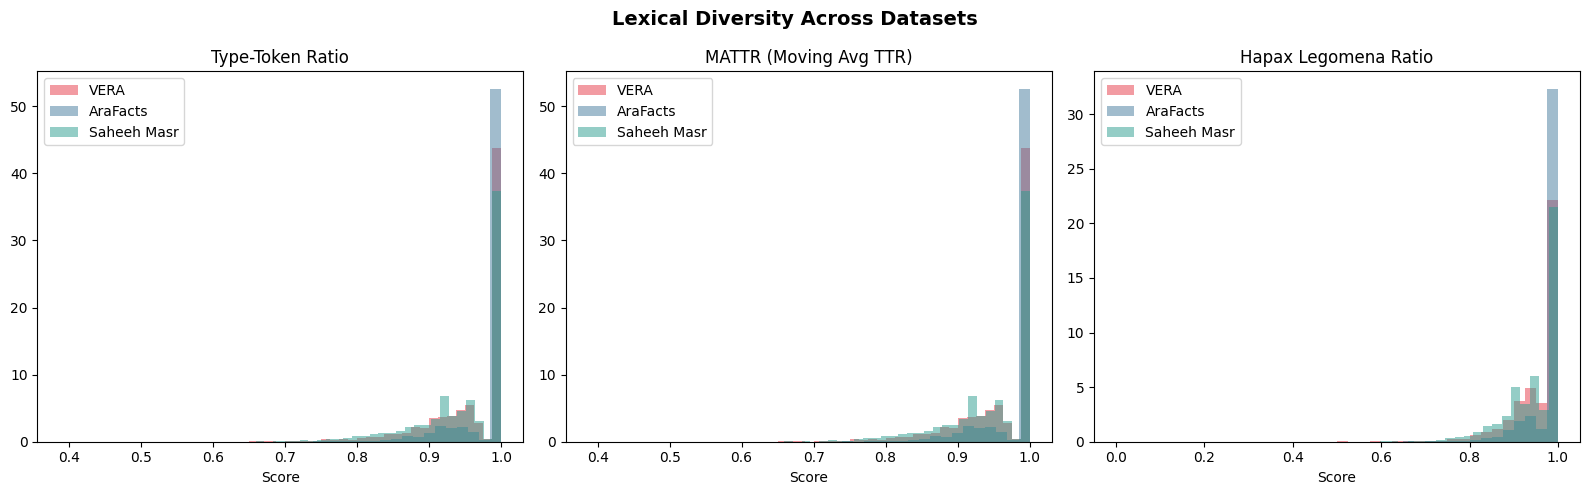

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['ttr', 'mattr', 'hapax']
labels  = ['Type-Token Ratio', 'MATTR (Moving Avg TTR)', 'Hapax Legomena Ratio']

for ax, metric, label in zip(axes, metrics, labels):
    for lex, name, color in [
        (vera_lex,     'VERA',        COLORS['VERA']),
        (arafacts_lex, 'AraFacts',    COLORS['AraFacts']),
        (saheeh_lex,   'Saheeh Masr', COLORS['Saheeh']),
    ]:
        ax.hist(lex[metric].dropna(), bins=40, alpha=0.5, label=name, color=color, density=True)
    ax.set_title(label)
    ax.set_xlabel('Score')
    ax.legend()

plt.suptitle('Lexical Diversity Across Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lexical_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Frequent Words & N-gram Analysis

**Why:** Reveals spurious correlations. If n-grams that are highly predictive of 'fake' in VERA appear only in 'real' Saheeh Masr articles, the model has learned inverse shortcuts.

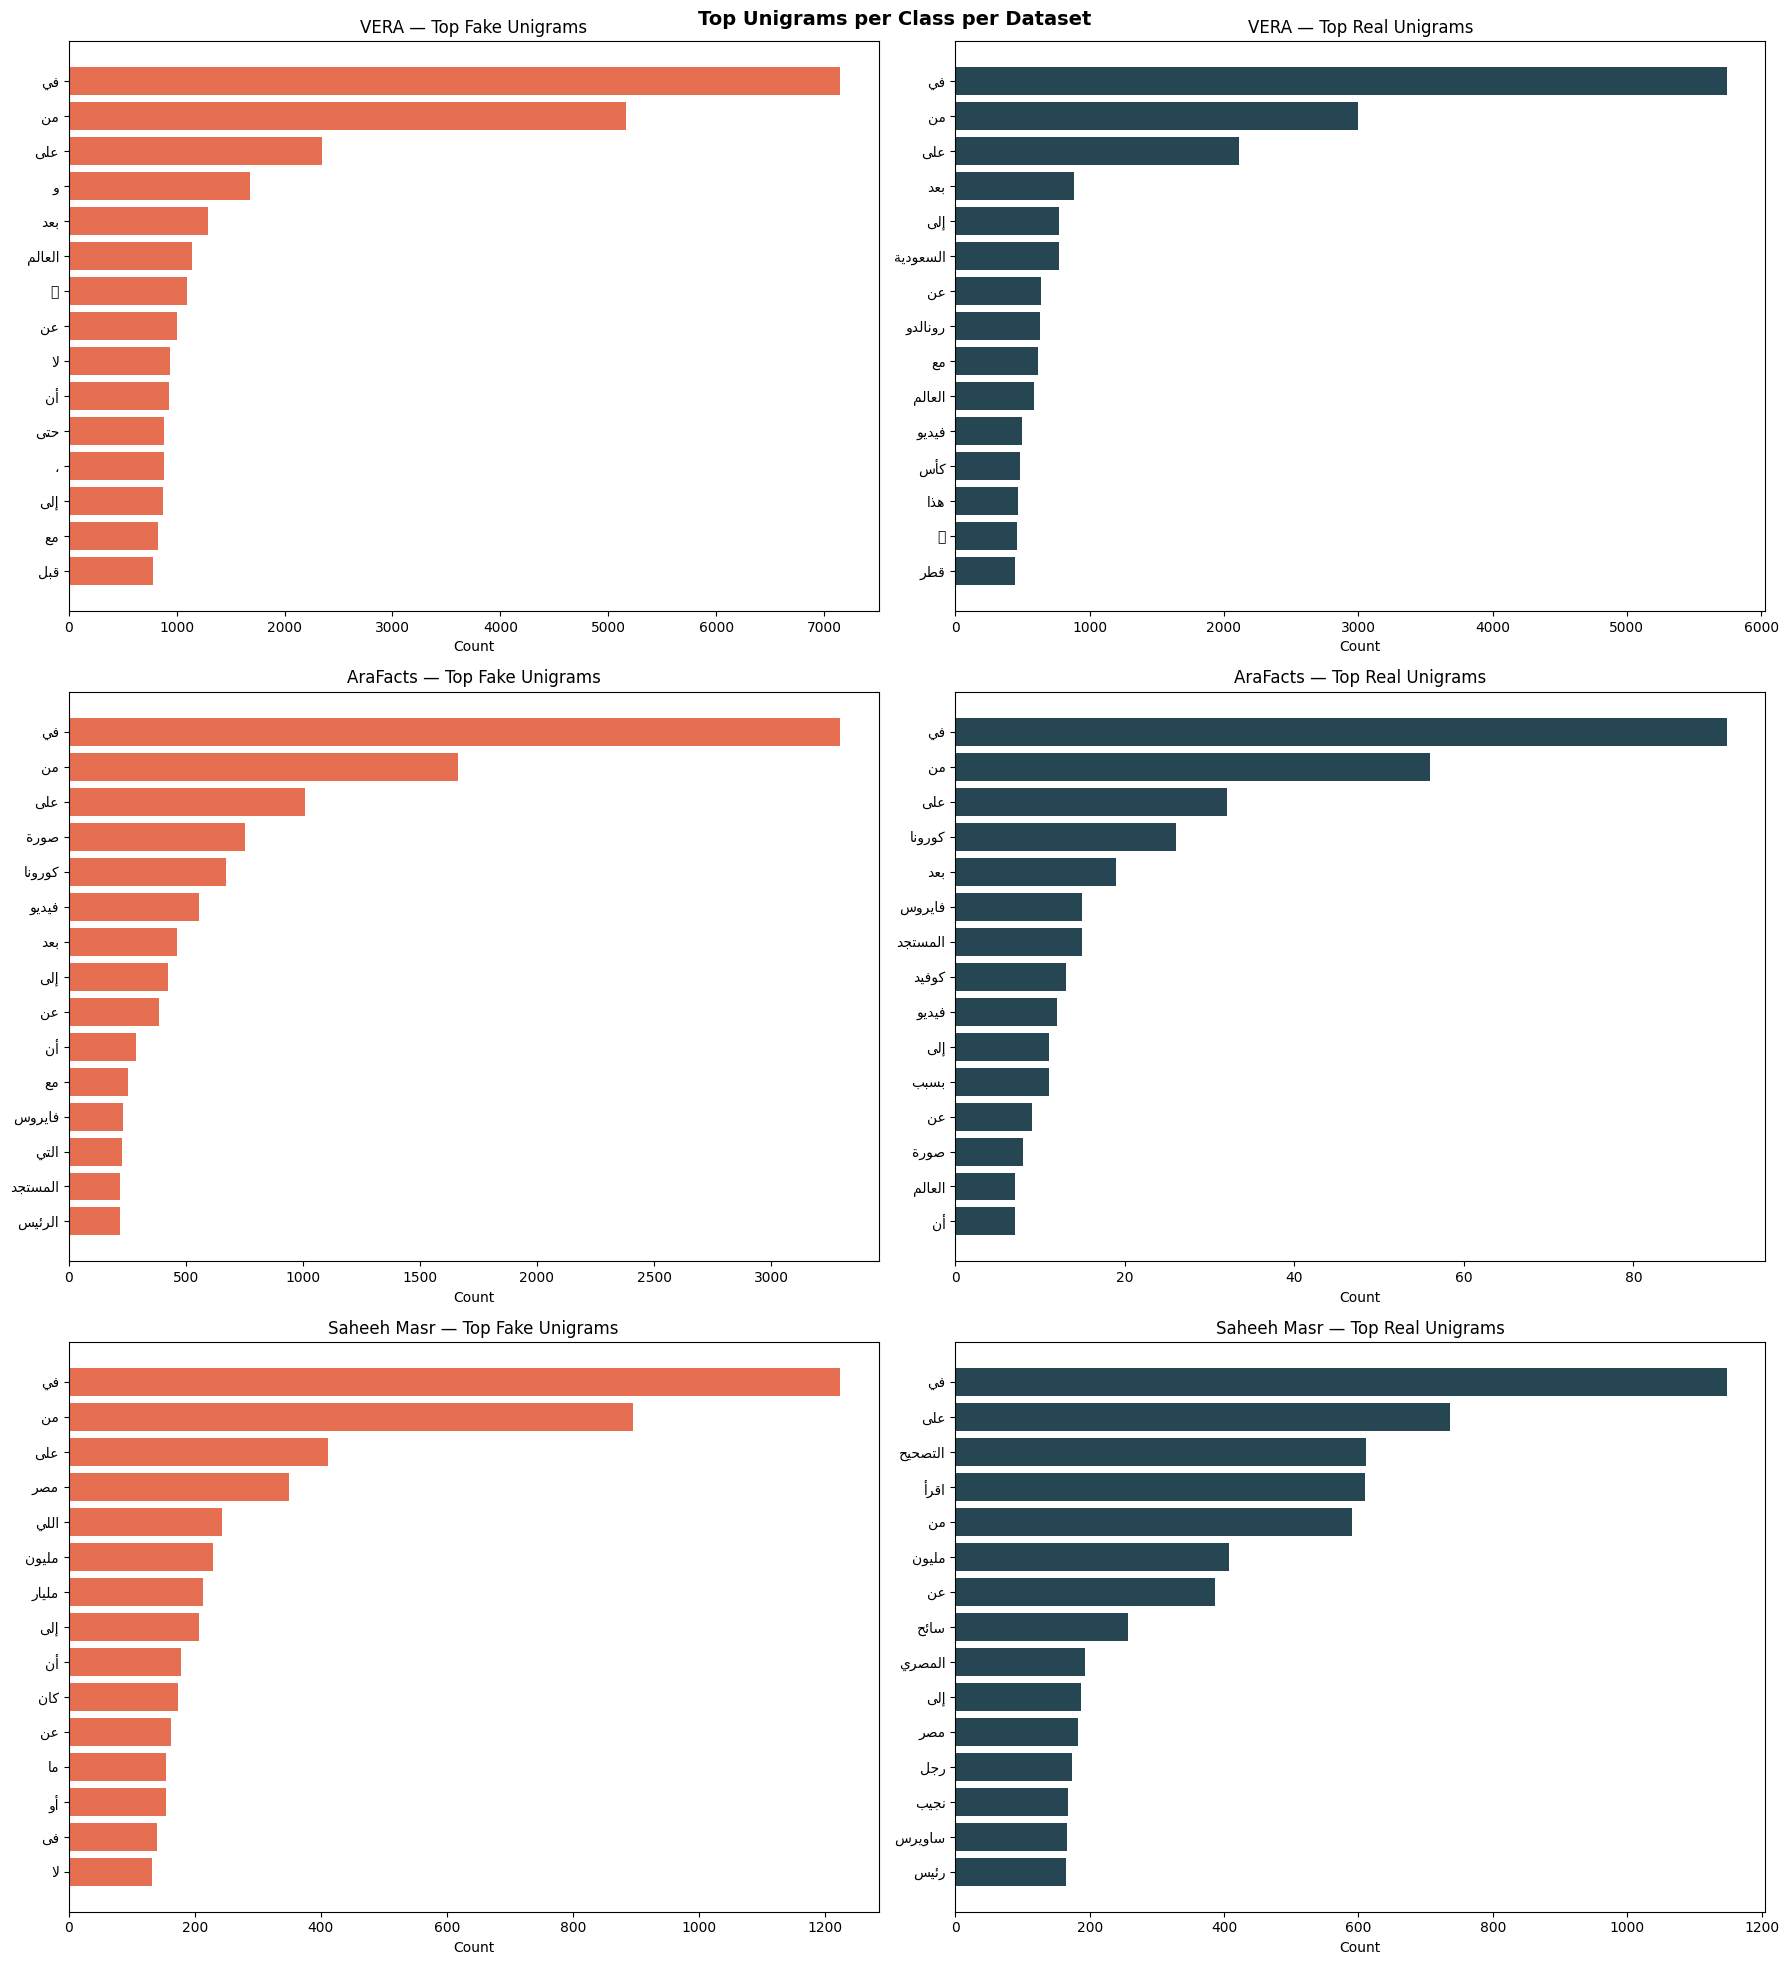

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

def get_top_ngrams(texts, n=1, top_k=20):
    """Return top-k n-grams with counts."""
    clean = [normalize_arabic(t) for t in texts]
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000,
                          token_pattern=r'[\u0600-\u06FF]+')
    X = vec.fit_transform(clean)
    totals = np.array(X.sum(axis=0)).flatten()
    vocab = {v: k for k, v in vec.vocabulary_.items()}
    top_idx = totals.argsort()[::-1][:top_k]
    return [(vocab[i], totals[i]) for i in top_idx]

def plot_ngrams(ax, ngrams, title, color):
    words, counts = zip(*ngrams)
    ax.barh([ar(w) for w in words][::-1], list(counts)[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Count')

# Per-label unigrams for each dataset
fig, axes = plt.subplots(3, 2, figsize=(18, 20))

for i, (df, name) in enumerate([(vera,'VERA'),(arafacts,'AraFacts'),(saheeh,'Saheeh Masr')]):
    fake_text = df[df['binary_label']==1]['text']
    real_text = df[df['binary_label']==0]['text']
    top_fake = get_top_ngrams(fake_text, n=1, top_k=15)
    top_real = get_top_ngrams(real_text, n=1, top_k=15)
    plot_ngrams(axes[i][0], top_fake, f'{name} — Top Fake Unigrams', COLORS['fake'])
    plot_ngrams(axes[i][1], top_real, f'{name} — Top Real Unigrams', COLORS['real'])

plt.suptitle('Top Unigrams per Class per Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ngrams_unigram.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# KEY DIAGNOSTIC: which top-20 VERA fake unigrams appear in Saheeh Masr real texts?
vera_fake_ngrams  = set(w for w, _ in get_top_ngrams(vera[vera['binary_label']==1]['text'], top_k=50))
saheeh_real_ngrams = set(w for w, _ in get_top_ngrams(saheeh[saheeh['binary_label']==0]['text'], top_k=200))

spurious_overlap = vera_fake_ngrams & saheeh_real_ngrams
print(f'VERA fake top-50 unigrams that appear in Saheeh Masr REAL top-200:')
print(spurious_overlap)
print(f'\nCount: {len(spurious_overlap)}')
print('🚨 HIGH overlap here = spurious correlations that invert on the test domain')

VERA fake top-50 unigrams that appear in Saheeh Masr REAL top-200:
{'في', 'ما', 'و', 'محمد', 'كأس', 'هذا', 'مصر', 'التي', 'كان', 'بعد', '،', 'اليوم', 'عام', 'العالم', 'قبل', 'قطر', 'كل', 'إلى', 'مع', 'يا', 'الذي', 'خلال', 'يوم', 'حتى', 'كانت', 'أن', 'لا', 'على', 'من', 'عن'}

Count: 30
🚨 HIGH overlap here = spurious correlations that invert on the test domain


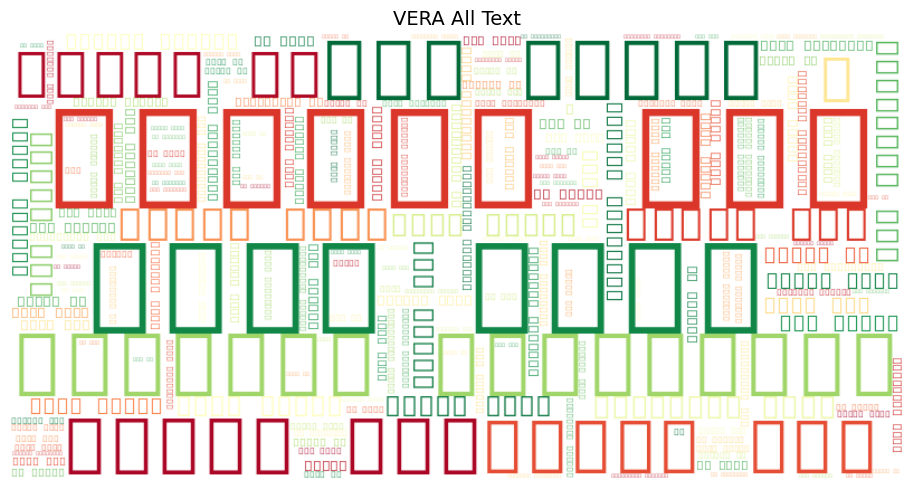

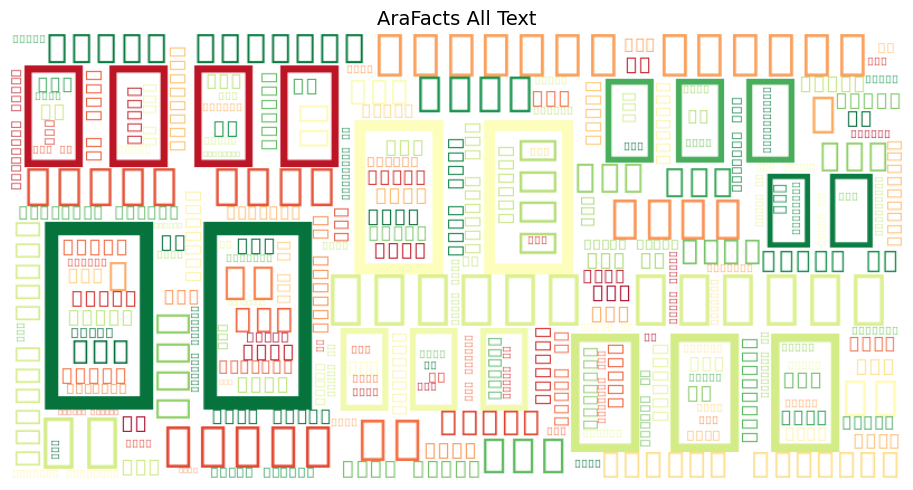

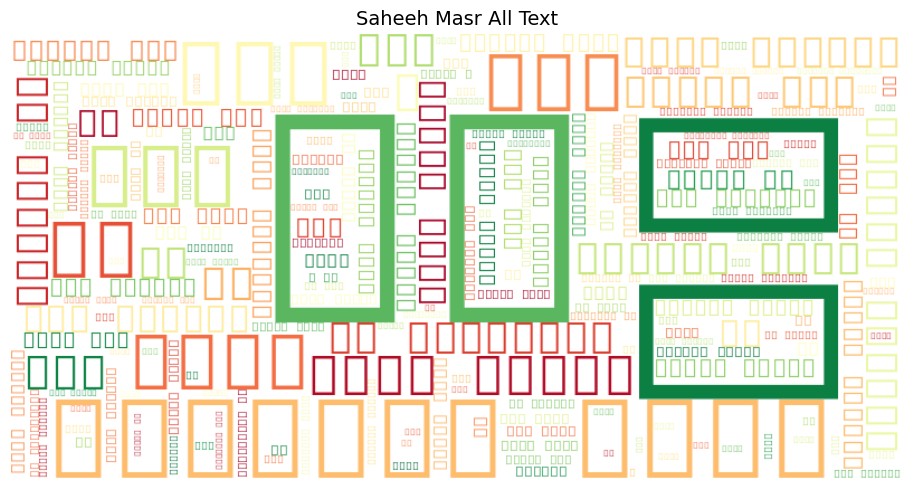

In [30]:
# Word clouds per dataset
def make_arabic_wordcloud(texts, title, color):
    text_joined = ' '.join(normalize_arabic(t) for t in texts)
    wc = WordCloud(
        font_path=None,  # update if you have an Arabic font path
        background_color='white',
        width=800, height=400,
        colormap='RdYlGn',
        regexp=r'[\u0600-\u06FF]+'
    ).generate(text_joined)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f'wordcloud_{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

make_arabic_wordcloud(vera['text'],     'VERA All Text',        COLORS['VERA'])
make_arabic_wordcloud(arafacts['text'], 'AraFacts All Text',   COLORS['AraFacts'])
make_arabic_wordcloud(saheeh['text'],   'Saheeh Masr All Text', COLORS['Saheeh'])

---
## 8. Duplicate & Near-Duplicate Detection

**Why:** Within-dataset duplicates inflate model confidence on repeated patterns. Cross-dataset near-duplicates are data leakage — if Saheeh Masr samples appear in training data, your generalization claims are invalid.

In [31]:
import hashlib
from datasketch import MinHash, MinHashLSH

def hash_text(text):
    return hashlib.md5(normalize_arabic(text).encode()).hexdigest()

# Exact duplicates within each dataset
for df, name in [(vera,'VERA'),(arafacts,'AraFacts'),(saheeh,'Saheeh Masr')]:
    df['text_hash'] = df['text'].apply(hash_text)
    n_exact = df.duplicated('text_hash').sum()
    pct = n_exact / len(df) * 100
    print(f'{name}: {n_exact} exact duplicates ({pct:.1f}%)')

VERA: 3715 exact duplicates (18.5%)
AraFacts: 14 exact duplicates (0.2%)
Saheeh Masr: 534 exact duplicates (17.7%)


In [32]:
# Near-duplicate detection using MinHash LSH (threshold=0.8 Jaccard similarity)
def build_minhash(text, num_perm=128):
    m = MinHash(num_perm=num_perm)
    for token in normalize_arabic(text).split():
        m.update(token.encode('utf-8'))
    return m

THRESHOLD = 0.8
NUM_PERM  = 128

print('Building MinHash LSH for cross-dataset near-duplicate detection...')
lsh = MinHashLSH(threshold=THRESHOLD, num_perm=NUM_PERM)

# Add all VERA and AraFacts samples to the LSH index
for i, row in tqdm(vera.iterrows(), total=len(vera), desc='Indexing VERA'):
    m = build_minhash(row['text'])
    lsh.insert(f'vera_{i}', m)

for i, row in tqdm(arafacts.iterrows(), total=len(arafacts), desc='Indexing AraFacts'):
    m = build_minhash(row['text'])
    try:
        lsh.insert(f'af_{i}', m)
    except ValueError:
        pass  # skip exact duplicates already in index

# Query with Saheeh Masr — check for leakage
leakage_hits = []
for i, row in tqdm(saheeh.iterrows(), total=len(saheeh), desc='Querying Saheeh Masr'):
    m = build_minhash(row['text'])
    results = lsh.query(m)
    if results:
        leakage_hits.append({'saheeh_idx': i, 'matches': results, 'text': row['text']})

print(f'\n=== Cross-dataset Near-Duplicate (Leakage) Results ===')
print(f'Saheeh Masr samples with near-duplicates in VERA/AraFacts: {len(leakage_hits)}')
if leakage_hits:
    print('🚨 DATA LEAKAGE DETECTED — inspect these samples!')
    for h in leakage_hits[:5]:
        print(f"  Saheeh idx {h['saheeh_idx']}: {h['text'][:80]}... matched {h['matches']}")
else:
    print('✅ No cross-dataset near-duplicates found — generalization claims are valid')

Building MinHash LSH for cross-dataset near-duplicate detection...


Indexing VERA:   0%|          | 0/20084 [00:00<?, ?it/s]

Indexing AraFacts:   0%|          | 0/6222 [00:00<?, ?it/s]

Querying Saheeh Masr:   0%|          | 0/3019 [00:00<?, ?it/s]


=== Cross-dataset Near-Duplicate (Leakage) Results ===
Saheeh Masr samples with near-duplicates in VERA/AraFacts: 2
🚨 DATA LEAKAGE DETECTED — inspect these samples!
  Saheeh idx 2487: ❌ نشرت عدد من الصفحات على فيسبوك وتويتر ومواقع إخبارية منها جريدة الشروق، صورة ل... matched ['vera_6560']
  Saheeh idx 2759: ❌ انتشر فيديو على تويتر، يظهر فيه حشود من المشيعين، وادعى البعض أنه من جنازة الم... matched ['vera_6549']


---
## 9. Noise Detection & Label Quality

**Why:** Mislabeled samples directly corrupt the decision boundary. AraFacts' 35+ label variants collapsed to binary almost certainly contains noise. Identifying and quantifying noise is essential for understanding negative transfer.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

def find_hard_samples(df, name, n_hard=50):
    """Use cross-validated TF-IDF + LR to find consistently mispredicted samples."""
    texts  = [normalize_arabic(t) for t in df['text']]
    labels = df['binary_label'].values

    vec = TfidfVectorizer(max_features=10000, token_pattern=r'[\u0600-\u06FF]+')
    X   = vec.fit_transform(texts)

    clf  = LogisticRegression(max_iter=500, C=1.0, class_weight='balanced')
    pred_proba = cross_val_predict(clf, X, labels, cv=3, method='predict_proba')

    # Confidence score: how sure is the model about the CORRECT class?
    correct_class_proba = pred_proba[np.arange(len(labels)), labels]
    pred_labels = pred_proba.argmax(axis=1)

    df_result = df.copy()
    df_result['correct_proba'] = correct_class_proba
    df_result['predicted']     = pred_labels
    df_result['is_wrong']      = (pred_labels != labels).astype(int)

    # Hard negatives: confidently wrong
    hard = df_result[df_result['is_wrong'] == 1].sort_values('correct_proba')

    print(f'\n=== {name} — Label Quality ===')
    print(f'Cross-validated accuracy: {(pred_labels == labels).mean()*100:.1f}%')
    print(f'Consistently wrong samples (hard negatives): {len(hard)}')
    print(f'% of dataset: {len(hard)/len(df)*100:.1f}%')
    print(f'\nTop 5 most suspicious (confidently mislabeled) samples:')
    for _, row in hard.head(5).iterrows():
        print(f"  Label={row['binary_label']} | Pred={row['predicted']} | "
              f"Confidence={1-row['correct_proba']:.2f} | Text: {str(row['text'])[:80]}")

    return df_result

vera_quality     = find_hard_samples(vera,     'VERA')
arafacts_quality = find_hard_samples(arafacts, 'AraFacts')
saheeh_quality   = find_hard_samples(saheeh,   'Saheeh Masr')


=== VERA — Label Quality ===
Cross-validated accuracy: 78.1%
Consistently wrong samples (hard negatives): 4392
% of dataset: 21.9%

Top 5 most suspicious (confidently mislabeled) samples:
  Label=1 | Pred=0 | Confidence=0.96 | Text: شاهد فيديو   إعصار ساولا في الصين   
  Label=1 | Pred=0 | Confidence=0.96 | Text: تقارير: مورينيو يوافق على تدريب أهلي جدة  جوزيه موربنيو مورينيو اهلي جدة الدوري 
  Label=1 | Pred=0 | Confidence=0.95 | Text: فيديو  مشاهد من إعصار هينامنور في كوريا الجنوبية    صحيفة المدينة 
  Label=0 | Pred=1 | Confidence=0.94 | Text: أول جنية مصري صدر بتاريخ ۳ ابريل ۱۸۹۹  وكان يساوي 7 جنيه ذهب اي ما يعادل الآن  1
  Label=1 | Pred=0 | Confidence=0.94 | Text: زار  مقتدى الصدر منزل   الارهابي قاسم سليماني مقدما التعازي لعائلة الإرهابي ويقو

=== AraFacts — Label Quality ===
Cross-validated accuracy: 96.7%
Consistently wrong samples (hard negatives): 204
% of dataset: 3.3%

Top 5 most suspicious (confidently mislabeled) samples:
  Label=0 | Pred=1 | Confidence=0.92 | Text: صور

In [34]:
# AraFacts-specific: check noise from ambiguous label mapping
print('=== AraFacts — Ambiguous Label Samples ===')
ambig = arafacts[arafacts['binary_label_raw'] == 2][['claim', 'source_label', 'binary_label']]
print(f'Total ambiguous labels mapped: {len(ambig)}')
print('\nAmbiguous label breakdown:')
print(arafacts[arafacts['binary_label_raw'] == 2]['source_label'].value_counts())
print('\nSample ambiguous entries:')
display(ambig.head(10))

=== AraFacts — Ambiguous Label Samples ===
Total ambiguous labels mapped: 343

Ambiguous label breakdown:
source_label
partially-fake    160
ساخر               52
sarcastic          35
انتقائي            30
مشكوك فيه          26
صحيح جزئياً        23
مجتزأ               6
opinion             6
 ساخر               3
 انتقائي            2
Name: count, dtype: int64

Sample ambiguous entries:


,claim,source_label,binary_label
66,الثلوج تغطي مدينة دمشق,sarcastic,1
108,شخص يؤدي حركات راقصة خلف رئيس وزراء إيطاليا ال...,ساخر,1
158,"تقارير في الإعلام العالمي تقول إنّ ""إسرائيل"" س...",انتقائي,1
207,شركة فايزر تصمم إعلاناً خاصًا بمناسبة عيد الحب...,ساخر,1
270,تيليغرام التطبيق الأكثر تنزيلًا في العالم خلال...,انتقائي,1
275,فحوص الـPCR قد لا تكشف السلالة البريطانية من ...,صحيح جزئياً,1
293,وصول جرعات الفودكا بدلًا من لقاح سبوتنيك للجزائر.,ساخر,1
333,‏👈🏼 المذيعة تسأل رئيس شركة فايزر : لماذا لم تت...,مجتزأ,1
364,صورة إبراهيموفيتش بقصة شعره الجديدة.,ساخر,1
424,صورة لهطولات ثلجية في مدينة الزرقاء أو الرصيفة...,ساخر,1


---
## 10. Named Entity Distribution (VERA Pre-extracted)

**Why:** VERA has pre-extracted NER columns (organizations, persons, places). Named entities are strongly domain-specific — an Algerian political figure never appears in Egyptian news. If the model latches onto entities as predictive features, it will systematically fail on Saheeh Masr.

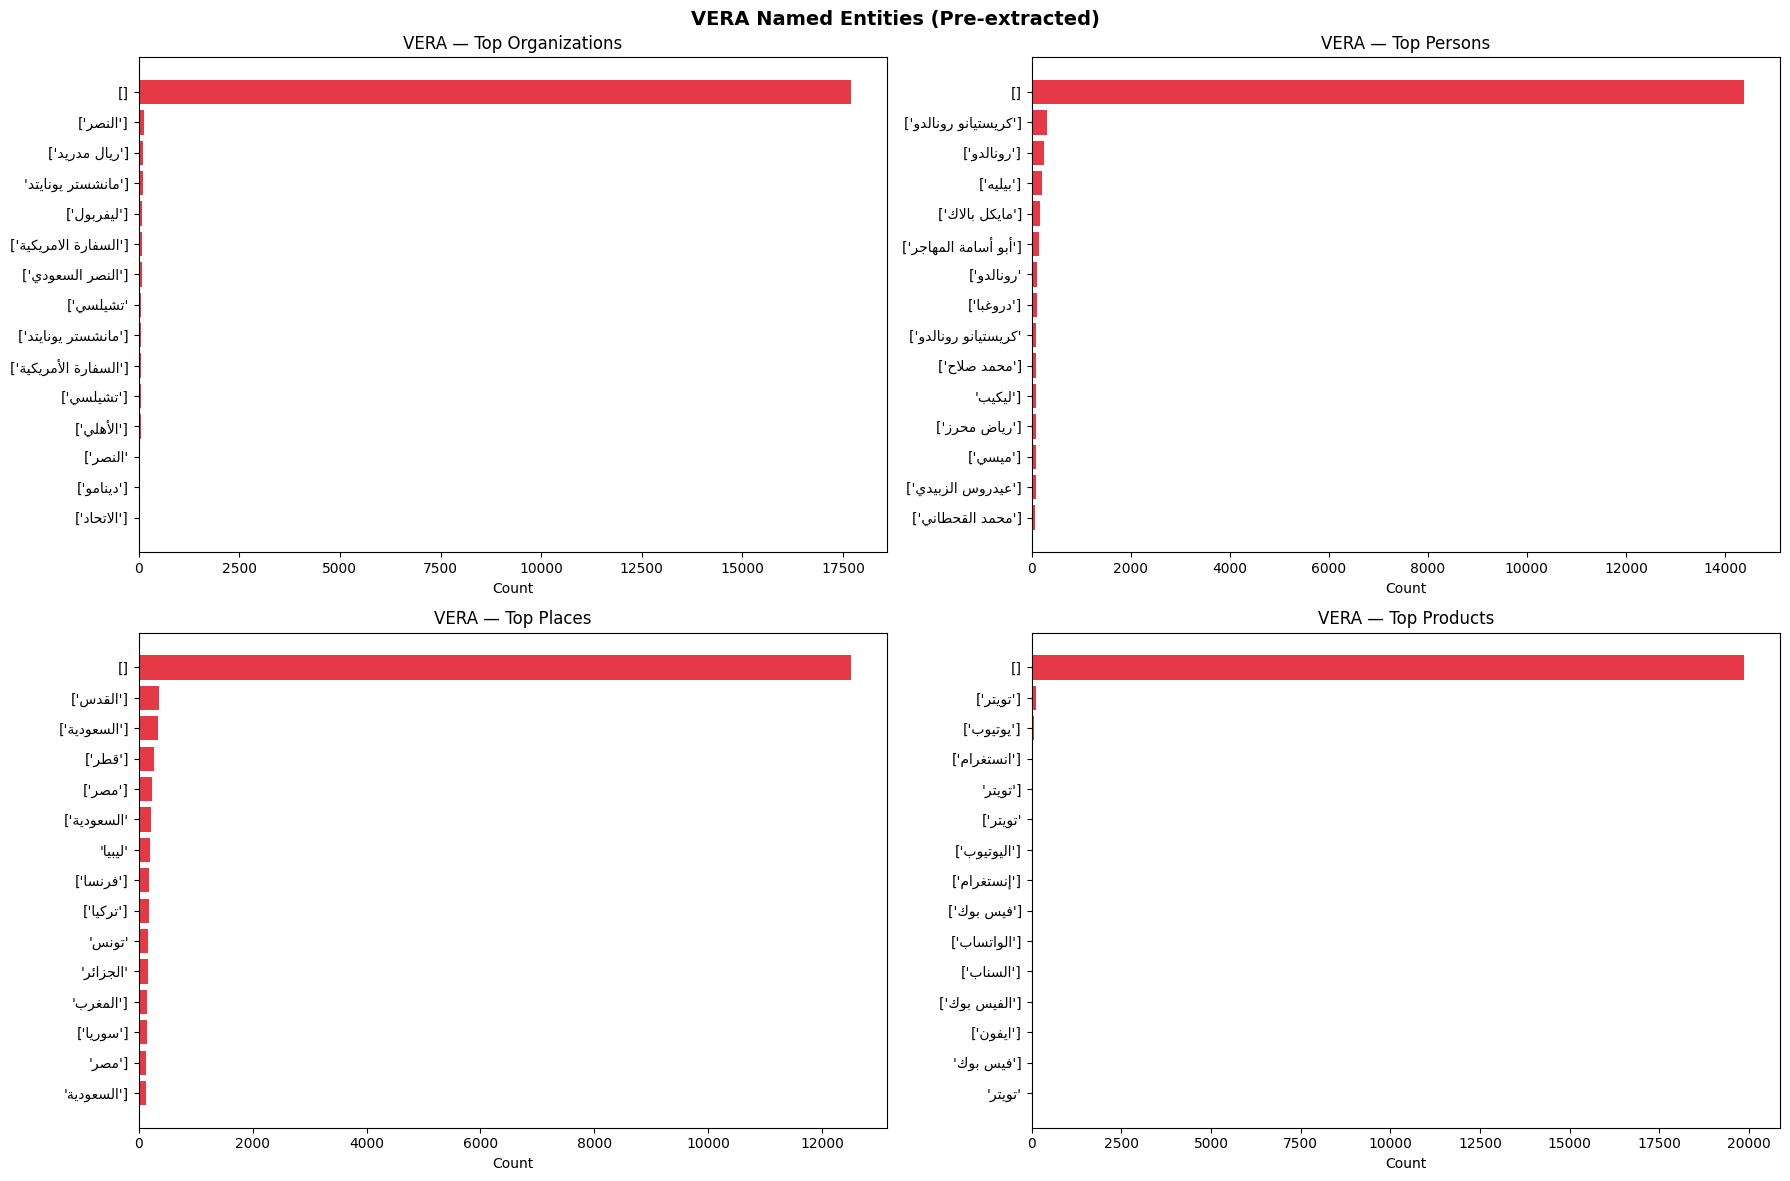

In [35]:
# VERA has pre-extracted NER: organizations, persons, places, products
# These are stored as comma-separated strings or lists

def extract_entities(col):
    """Parse comma-separated entity strings."""
    all_ents = []
    for val in col.dropna():
        if isinstance(val, str) and val.strip():
            ents = [e.strip() for e in val.split(',') if e.strip()]
            all_ents.extend(ents)
    return Counter(all_ents)

entity_types = ['organizations', 'persons', 'places', 'products']
vera_entities = {}
for etype in entity_types:
    if etype in vera.columns:
        vera_entities[etype] = extract_entities(vera[etype])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, etype in zip(axes.flatten(), entity_types):
    if etype in vera_entities and vera_entities[etype]:
        top15 = vera_entities[etype].most_common(15)
        words, counts = zip(*top15)
        ax.barh([ar(w) for w in words][::-1], list(counts)[::-1], color=COLORS['VERA'])
        ax.set_title(f'VERA — Top {etype.capitalize()}')
        ax.set_xlabel('Count')

plt.suptitle('VERA Named Entities (Pre-extracted)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vera_entities.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Per-label entity analysis: are certain entities strongly predictive of fake/real in VERA?
for etype in ['organizations', 'persons', 'places']:
    if etype not in vera.columns:
        continue
    fake_ents = extract_entities(vera[vera['binary_label']==1][etype])
    real_ents = extract_entities(vera[vera['binary_label']==0][etype])

    # PMI-like: entities more in fake than real
    all_ents = set(fake_ents.keys()) | set(real_ents.keys())
    scores = []
    for ent in all_ents:
        f = fake_ents.get(ent, 0)
        r = real_ents.get(ent, 0)
        if f + r > 5:  # minimum frequency filter
            ratio = (f + 1) / (r + 1)
            scores.append((ent, ratio, f, r))

    scores.sort(key=lambda x: -x[1])
    print(f'\n=== {etype} — Most Fake-Associated (VERA) ===')
    for ent, ratio, f, r in scores[:10]:
        print(f'  {ent:30s} | fake:{f:4d} | real:{r:4d} | ratio:{ratio:.2f}')

print('\n💡 Check if these entities appear in Saheeh Masr real articles — if yes, spurious correlation confirmed')


=== organizations — Most Fake-Associated (VERA) ===
  ['دينامو']                     | fake:  45 | real:   0 | ratio:46.00
  ['البرتغال']                   | fake:  27 | real:   0 | ratio:28.00
  'الريال'                       | fake:  26 | real:   0 | ratio:27.00
  'برشلونة']                     | fake:  23 | real:   0 | ratio:24.00
  'الاتحاد']                     | fake:  38 | real:   1 | ratio:19.50
  ['السفارة الأمريكية']          | fake:  57 | real:   3 | ratio:14.50
  ['السفارة التركية']            | fake:  13 | real:   0 | ratio:14.00
  ['الفيفا']                     | fake:  13 | real:   0 | ratio:14.00
  ['الريال'                      | fake:  13 | real:   0 | ratio:14.00
  'بتعاطيهم'                     | fake:  12 | real:   0 | ratio:13.00

=== persons — Most Fake-Associated (VERA) ===
  ['مايكل بالاك']                | fake: 176 | real:   0 | ratio:177.00
  ['دانيال باديسلاف']            | fake:  66 | real:   0 | ratio:67.00
  ['بالاك']                      | fake:  56 | 

---
## 11. Social Media Features (VERA-specific)

**Why:** VERA's social media metadata (hashtags, emojis, engagement counts) may have been implicitly used by the model if they appear in the text or indirectly in fine-tuning. These features are completely absent in Saheeh Masr.

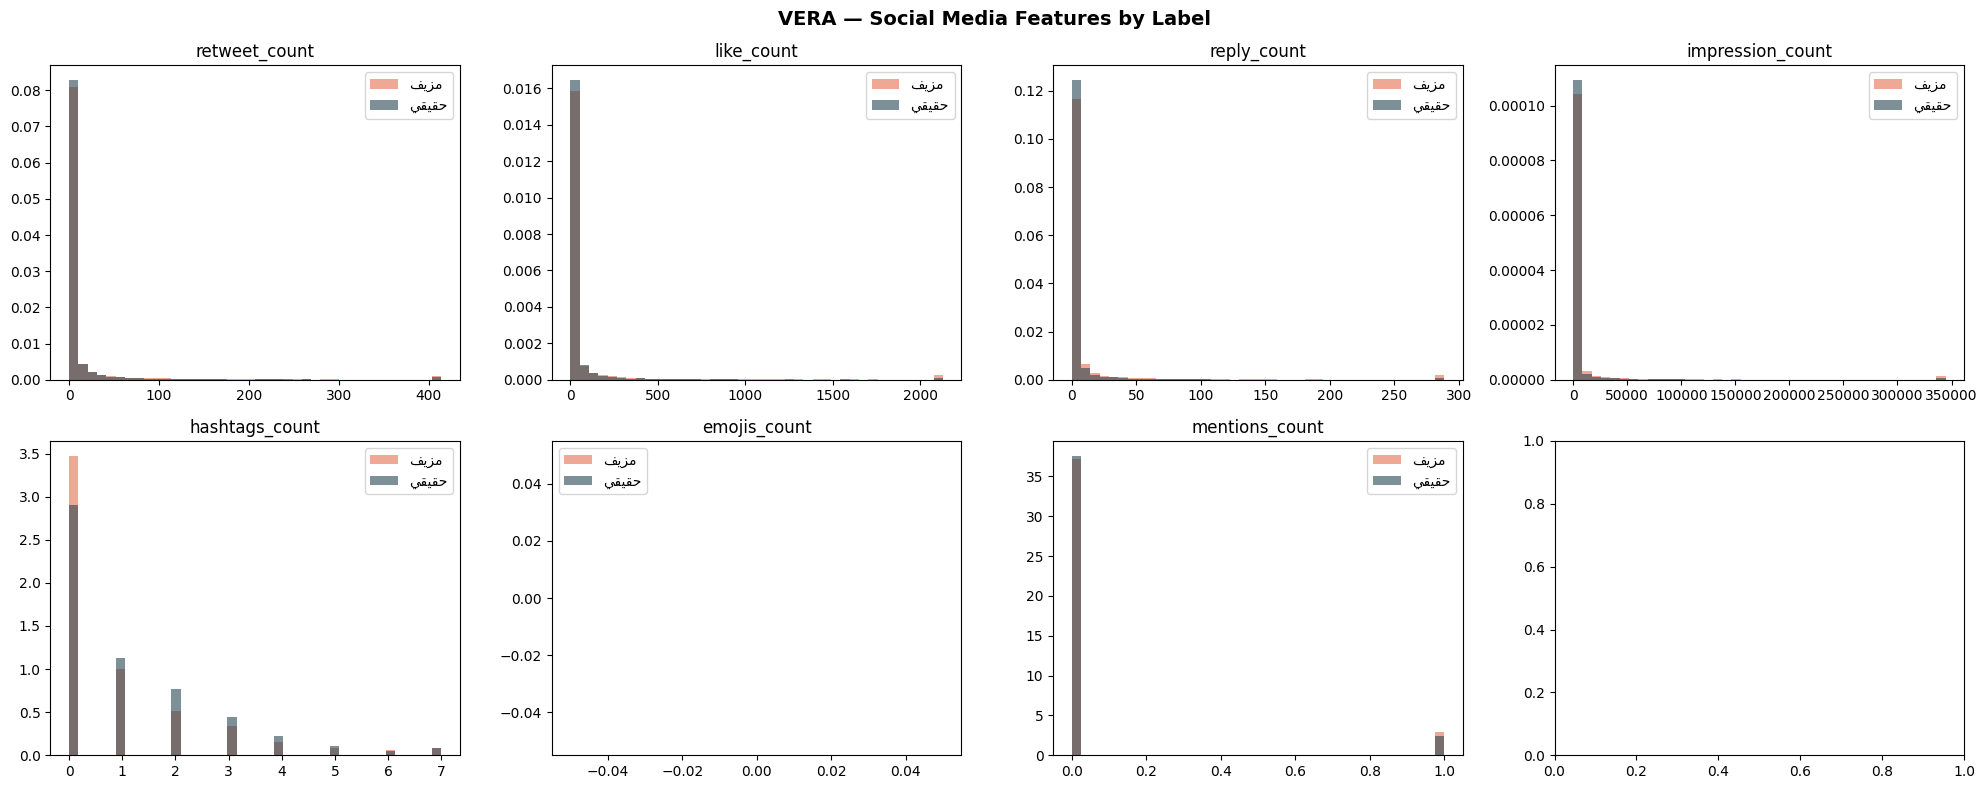

Mann-Whitney U test (fake vs real) for social features:
  retweet_count            : p=0.0349 🚨 SIGNIFICANT
  like_count               : p=0.0000 🚨 SIGNIFICANT
  reply_count              : p=0.0000 🚨 SIGNIFICANT
  impression_count         : p=0.0000 🚨 SIGNIFICANT
  hashtags_count           : p=0.0000 🚨 SIGNIFICANT
  mentions_count           : p=0.0017 🚨 SIGNIFICANT


In [37]:
# VERA social media statistics
social_cols = ['retweet_count', 'like_count', 'reply_count', 'impression_count',
               'hashtags_count', 'emojis_count', 'mentions_count']

existing_cols = [c for c in social_cols if c in vera.columns]
for col in existing_cols:
    vera[col] = pd.to_numeric(vera[col], errors='coerce')
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(existing_cols):
    ax = axes[i]
    for label, color in [(1, COLORS['fake']), (0, COLORS['real'])]:
        data = vera[vera['binary_label']==label][col].clip(
            upper=vera[col].quantile(0.99)).dropna()
        ax.hist(data, bins=40, alpha=0.6,
                label=ar('مزيف') if label==1 else ar('حقيقي'),
                color=color, density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle('VERA — Social Media Features by Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vera_social.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test per feature
from scipy.stats import mannwhitneyu
print('Mann-Whitney U test (fake vs real) for social features:')
for col in existing_cols:
    fake_vals = vera[vera['binary_label']==1][col].dropna()
    real_vals = vera[vera['binary_label']==0][col].dropna()
    if len(fake_vals) > 10 and len(real_vals) > 10:
        stat, p = mannwhitneyu(fake_vals, real_vals, alternative='two-sided')
        sig = '🚨 SIGNIFICANT' if p < 0.05 else '  not sig'
        print(f'  {col:25s}: p={p:.4f} {sig}')

---
## 12. Topic Modeling (BERTopic)

**Why:** Topic mismatch (not just dialect) is the most likely cause of cross-domain failure. BERTopic reveals whether VERA covers North African political topics, AraFacts covers MSA health/international topics, and Saheeh Masr covers Egyptian domestic topics — with minimal overlap.

In [5]:
from bertopic import BERTopic
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer

# BERTopic with Arabic-friendly settings
arabic_vectorizer = CountVectorizer(
    token_pattern=r'[\u0600-\u06FF]+',
    min_df=3,
    ngram_range=(1, 2)
)

umap_model = UMAP(n_components=5, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)

topic_model = BERTopic(
    language='multilingual',
    vectorizer_model=arabic_vectorizer,
    umap_model=umap_model,
    min_topic_size=20,
    nr_topics='auto',
    verbose=True
)

# Combine all texts with dataset labels
all_texts   = list(vera['text']) + list(arafacts['text']) + list(saheeh['text'])
all_sources = ['VERA']*len(vera) + ['AraFacts']*len(arafacts) + ['Saheeh']*len(saheeh)

print('Fitting BERTopic (this takes several minutes on Colab)...')
topics, probs = topic_model.fit_transform(all_texts)
print(f'Found {topic_model.get_topic_info().shape[0]-1} topics')

2026-06-19 03:46:30,935 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic (this takes several minutes on Colab)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/917 [00:00<?, ?it/s]

2026-06-19 04:04:14,460 - BERTopic - Embedding - Completed ✓
2026-06-19 04:04:14,463 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-19 04:05:23,128 - BERTopic - Dimensionality - Completed ✓
2026-06-19 04:05:23,131 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-19 04:05:33,220 - BERTopic - Cluster - Completed ✓
2026-06-19 04:05:33,221 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-06-19 04:05:35,856 - BERTopic - Representation - Completed ✓
2026-06-19 04:05:35,858 - BERTopic - Topic reduction - Reducing number of topics
2026-06-19 04:05:38,447 - BERTopic - Topic reduction - Reduced number of topics from 353 to 241


Found 240 topics


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9481,-1_على_في_من_صورة,"[على, في, من, صورة, مع, عن, بعد, فيديو, و, الله]",[شرطي اسرائيلي يخنق طفلا فلسطينيا حتى الموت يو...
1,0,2434,0_ثم_الحجاج_يأتون_المكرمة,"[ثم, الحجاج, يأتون, المكرمة, الله, من المغرب, ...",[الحجاج عام 1934 م يأتون من المغرب ليقابلوا حج...
2,1,677,1_مليار_جنيه_مصر_دولار,"[مليار, جنيه, مصر, دولار, مليار دولار, مليار ج...",[في سنة واحدة حكم فيها الإخوان ارتفع الدين الخ...
3,2,533,2_تركيا_زلزال_الزلزال_أردوغان,"[تركيا, زلزال, الزلزال, أردوغان, التركية, هاتا...","[تركيا:لحظات مرعبة في هاتاي أثناء الزلزال. , أ..."
4,3,437,3_روسيا_أوكرانيا_بوتين_روسية,"[روسيا, أوكرانيا, بوتين, روسية, الناتو, تحطم ط...",[محمد بن زايد : التقيت الرئيس الروسي فلادي...
5,4,430,4_ايلون ماسك_ايلون_ماكرون_الله,"[ايلون ماسك, ايلون, ماكرون, الله, ذمار, الرسول...","[ايلون ماسك فرع ذمار , ايلون ماسك فرع ذمار ..."
6,5,390,5_تل أبيب_تل_أبيب_هروب جماعي,"[تل أبيب, تل, أبيب, هروب جماعي, غزة, جماعي, هر...",[لحظة هروب جماعي لعشرات المستوطنين من شواطئ تل...
7,6,362,6_رونالدو_استبعاد_ليكيب_سيعتزل,"[رونالدو, استبعاد, ليكيب, سيعتزل, رونالدو من, ...",[عاااااااجل ليكيب : كريستيانو رونالدو اخبر زمل...
8,7,312,7_بيليه_البرازيلية_البرازيلية بيليه_وفاة,"[بيليه, البرازيلية, البرازيلية بيليه, وفاة, أس...","[ وفاة أسطورة كرة القدم البرازيلية بيليه, وفا..."
9,8,305,8_حتى_فلسطينيا حتى_طفلا فلسطينيا_فلسطينيا,"[حتى, فلسطينيا حتى, طفلا فلسطينيا, فلسطينيا, ح...",[ ضابط شرطة إسرائيلي يخنق طفلا فلسطينيا حتى ا...


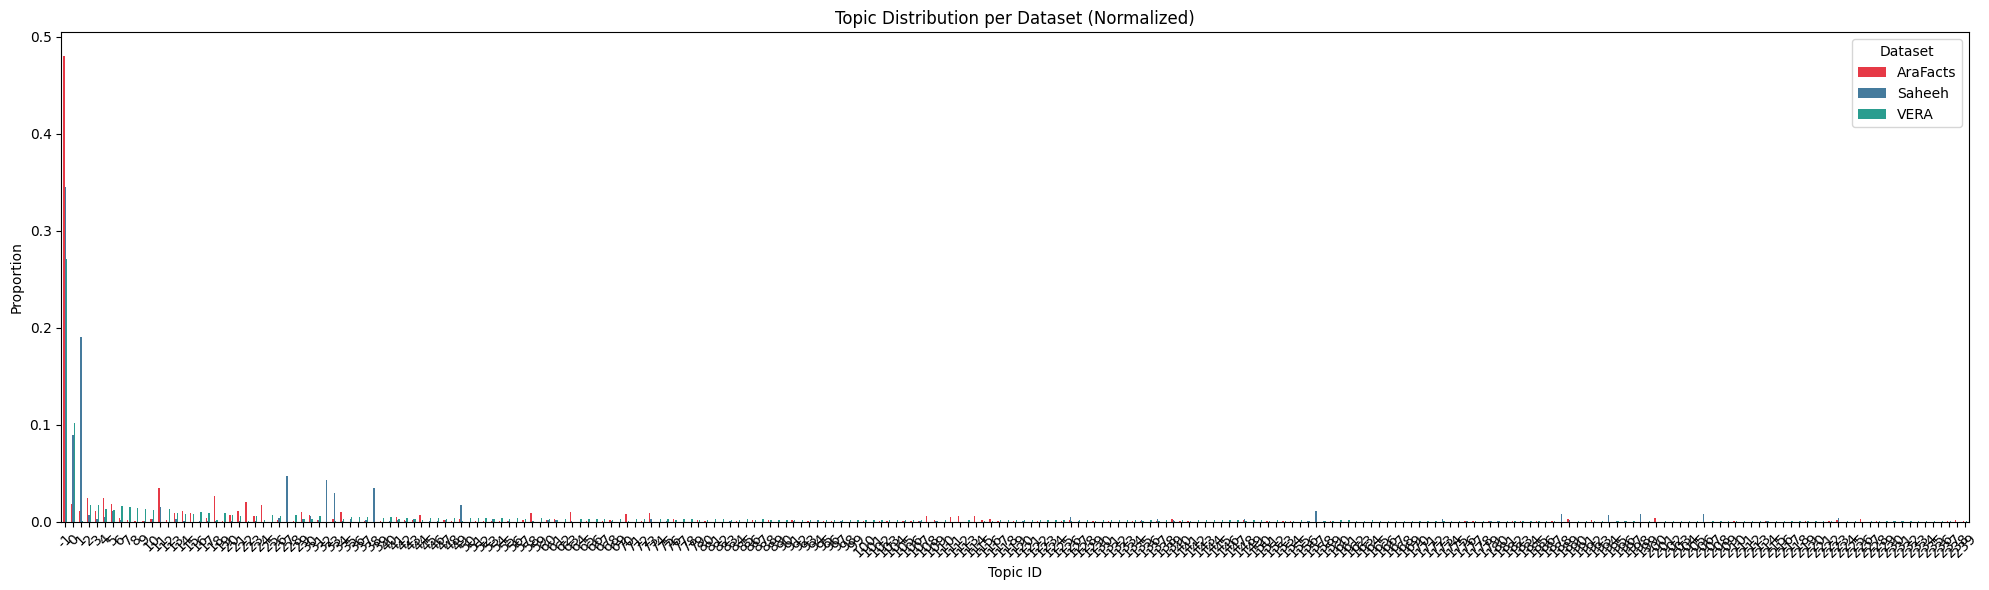

=== Jensen-Shannon Divergence Between Topic Distributions ===
VERA vs Saheeh Masr  : 0.5320
AraFacts vs Saheeh   : 0.4743
VERA vs AraFacts     : 0.4152

Interpretation: JS = 0 (identical), JS = 1 (completely different)
JS > 0.5 = severe topic mismatch


In [10]:
# Topic info
topic_info = topic_model.get_topic_info()
display(topic_info.head(20))

# Topic distribution per dataset
df_topics = pd.DataFrame({
    'topic': topics,
    'source': all_sources,
})

topic_by_ds = df_topics.groupby(['source', 'topic']).size().unstack(fill_value=0)
topic_by_ds_norm = topic_by_ds.div(topic_by_ds.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(20, 6))
topic_by_ds_norm.T.plot(kind='bar', ax=ax, color=[COLORS['VERA'],COLORS['AraFacts'],COLORS['Saheeh']])
ax.set_title('Topic Distribution per Dataset (Normalized)')
ax.set_xlabel('Topic ID')
ax.set_ylabel('Proportion')
ax.legend(title='Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# JS Divergence between datasets
from scipy.spatial.distance import jensenshannon

# Filter topics that appear in all three datasets
vera_dist   = topic_by_ds_norm.loc['VERA'].fillna(0).values
af_dist     = topic_by_ds_norm.loc['AraFacts'].fillna(0).values
saheeh_dist = topic_by_ds_norm.loc['Saheeh'].fillna(0).values

print('=== Jensen-Shannon Divergence Between Topic Distributions ===')
print(f'VERA vs Saheeh Masr  : {jensenshannon(vera_dist,   saheeh_dist):.4f}')
print(f'AraFacts vs Saheeh   : {jensenshannon(af_dist,     saheeh_dist):.4f}')
print(f'VERA vs AraFacts     : {jensenshannon(vera_dist,   af_dist):.4f}')
print('\nInterpretation: JS = 0 (identical), JS = 1 (completely different)')
print('JS > 0.5 = severe topic mismatch')

---
## 13. MARBERTv2 Embedding Space Visualization (UMAP / t-SNE)

**Why:** This is the most powerful single visualization for your GP presentation. If dataset clusters are separated in embedding space, the model is making decisions in a region it was never trained in. This is direct, visual evidence of domain shift.

In [12]:
from transformers import AutoTokenizer, AutoModel

model_name = "UBC-NLP/MARBERTv2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

In [38]:
import torch
from transformers import AutoModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

print('Loading MARBERTv2 model...')
marbert = AutoModel.from_pretrained('UBC-NLP/MARBERTv2').to(device)
marbert.eval()

def get_embeddings(texts, batch_size=32, max_length=128):
    """Get CLS token embeddings from MARBERTv2."""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Embedding'):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            out = marbert(**enc)
        cls = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls)
    return np.vstack(all_embeddings)

# Sample to keep Colab tractable (1500 per dataset)
N_SAMPLE = 1500
vera_sample     = vera.sample(min(N_SAMPLE, len(vera)),     random_state=42)
arafacts_sample = arafacts.sample(min(N_SAMPLE, len(arafacts)), random_state=42)
saheeh_sample   = saheeh.sample(min(N_SAMPLE, len(saheeh)), random_state=42)

print('Computing MARBERTv2 embeddings...')
vera_emb     = get_embeddings(list(vera_sample['text']))
arafacts_emb = get_embeddings(list(arafacts_sample['text']))
saheeh_emb   = get_embeddings(list(saheeh_sample['text']))

all_emb     = np.vstack([vera_emb, arafacts_emb, saheeh_emb])
all_sources = ['VERA']*len(vera_sample) + ['AraFacts']*len(arafacts_sample) + ['Saheeh']*len(saheeh_sample)
all_labels  = (list(vera_sample['binary_label']) +
               list(arafacts_sample['binary_label']) +
               list(saheeh_sample['binary_label']))

print(f'Total embeddings: {all_emb.shape}')

Using device: cpu
Loading MARBERTv2 model...
Computing MARBERTv2 embeddings...


Embedding:   0%|          | 0/47 [00:00<?, ?it/s]

Embedding:   0%|          | 0/47 [00:00<?, ?it/s]

Embedding:   0%|          | 0/47 [00:00<?, ?it/s]

Total embeddings: (4500, 768)


In [39]:
from umap import UMAP

print('Running UMAP...')
umap_2d = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
               metric='cosine', random_state=42)
emb_2d = umap_2d.fit_transform(all_emb)

df_plot = pd.DataFrame({
    'x': emb_2d[:, 0],
    'y': emb_2d[:, 1],
    'dataset': all_sources,
    'label': ['Fake' if l==1 else 'Real' for l in all_labels],
})

# ── Plot 1: Color by Dataset ──────────────────────────────────────
fig = px.scatter(
    df_plot, x='x', y='y', color='dataset',
    color_discrete_map={'VERA': COLORS['VERA'],
                        'AraFacts': COLORS['AraFacts'],
                        'Saheeh': COLORS['Saheeh']},
    opacity=0.5,
    title='MARBERTv2 Embedding Space — Colored by Dataset (UMAP)',
    labels={'x': 'UMAP-1', 'y': 'UMAP-2'}
)
fig.update_traces(marker=dict(size=4))
fig.show()
fig.write_html('umap_by_dataset.html')

print('\n🔍 KEY INTERPRETATION:')
print('  - Well-separated clusters → severe domain shift → model has no experience in Saheeh region')
print('  - Mixed clusters → domain shift is smaller than expected → look at label separability')

Running UMAP...



🔍 KEY INTERPRETATION:
  - Well-separated clusters → severe domain shift → model has no experience in Saheeh region
  - Mixed clusters → domain shift is smaller than expected → look at label separability


In [40]:
# ── Plot 2: Color by Label ────────────────────────────────────────
fig = px.scatter(
    df_plot, x='x', y='y', color='label',
    color_discrete_map={'Fake': COLORS['fake'], 'Real': COLORS['real']},
    opacity=0.5,
    title='MARBERTv2 Embedding Space — Colored by Label (UMAP)',
    labels={'x': 'UMAP-1', 'y': 'UMAP-2'}
)
fig.update_traces(marker=dict(size=4))
fig.show()
fig.write_html('umap_by_label.html')

# ── Plot 3: Color by Dataset × Label combined ─────────────────────
df_plot['group'] = df_plot['dataset'] + ' — ' + df_plot['label']
fig = px.scatter(
    df_plot, x='x', y='y', color='group',
    opacity=0.5,
    title='MARBERTv2 Embedding Space — Dataset × Label (UMAP)',
    labels={'x': 'UMAP-1', 'y': 'UMAP-2'}
)
fig.update_traces(marker=dict(size=4))
fig.show()
fig.write_html('umap_combined.html')

print('Interactive HTML files saved — open them in a browser for full interactivity')

Interactive HTML files saved — open them in a browser for full interactivity


Running PCA → t-SNE...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 4500 samples in 0.001s...
[t-SNE] Computed neighbors for 4500 samples in 0.547s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4500
[t-SNE] Computed conditional probabilities for sample 2000 / 4500
[t-SNE] Computed conditional probabilities for sample 3000 / 4500
[t-SNE] Computed conditional probabilities for sample 4000 / 4500
[t-SNE] Computed conditional probabilities for sample 4500 / 4500
[t-SNE] Mean sigma: 0.000012
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.525818
[t-SNE] KL divergence after 1000 iterations: 1.683099


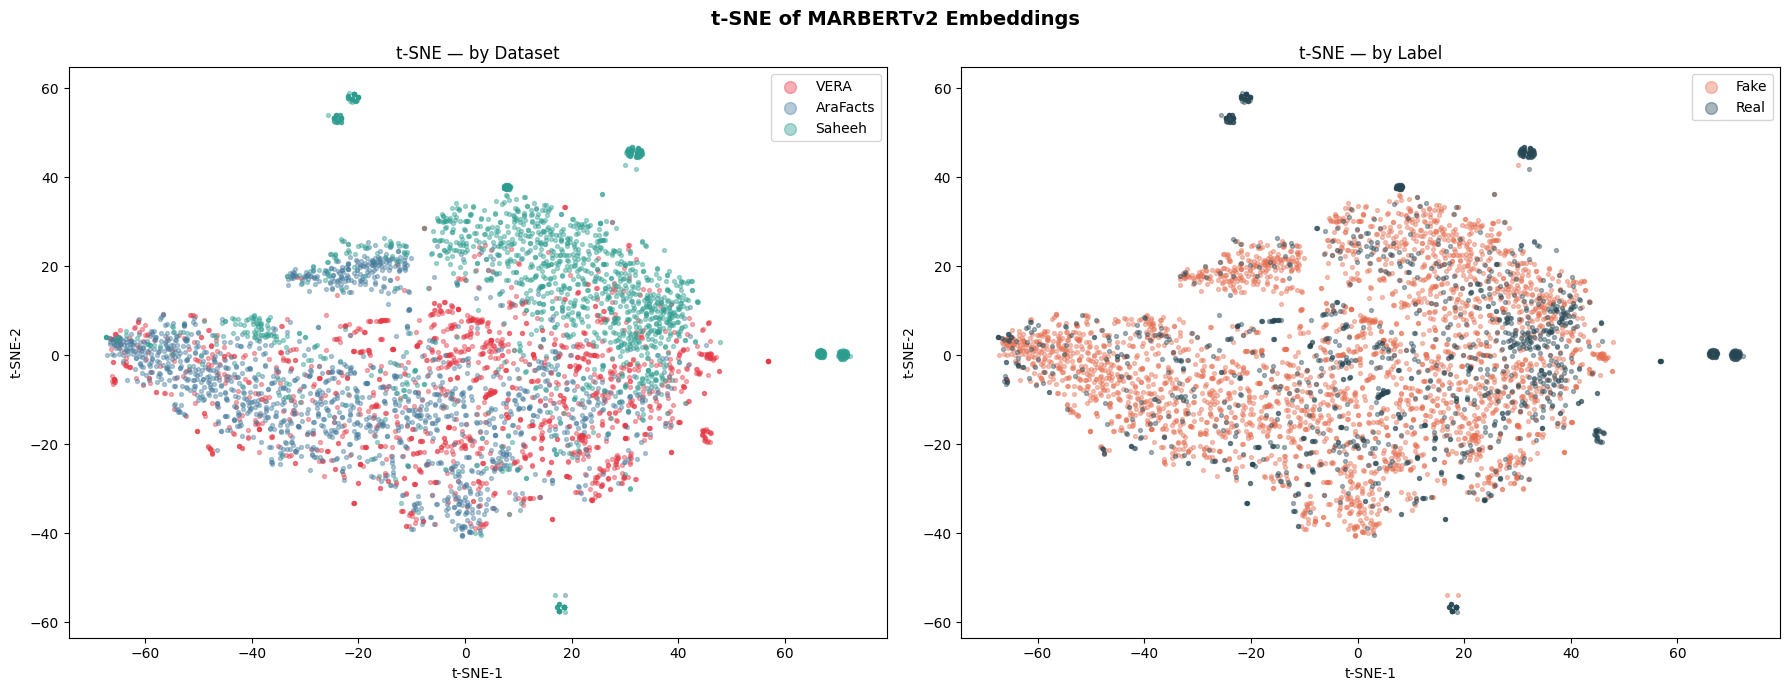

In [41]:
# t-SNE as a cross-check
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# PCA first to 50 dims for speed
print('Running PCA → t-SNE...')
pca = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(all_emb)

tsne = TSNE(n_components=2, perplexity=50, n_iter=1000, random_state=42, verbose=1)
emb_tsne = tsne.fit_transform(emb_pca)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, color_col, cmap, title in [
    (axes[0], 'dataset',  None, 't-SNE — by Dataset'),
    (axes[1], 'label',    None, 't-SNE — by Label'),
]:
    groups = df_plot[color_col].unique()
    palette = {
        'VERA': COLORS['VERA'], 'AraFacts': COLORS['AraFacts'], 'Saheeh': COLORS['Saheeh'],
        'Fake': COLORS['fake'], 'Real': COLORS['real']
    }
    for g in groups:
        mask = df_plot[color_col] == g
        ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
                   c=palette.get(g, 'grey'), label=g, alpha=0.4, s=8)
    ax.set_title(title)
    ax.legend(markerscale=3)
    ax.set_xlabel('t-SNE-1')
    ax.set_ylabel('t-SNE-2')

plt.suptitle('t-SNE of MARBERTv2 Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Domain Shift Quantification (A-distance & MMD)

**Why:** Gives you a single, citable number that quantifies domain shift rigorously. You can say 'A-distance between VERA and Saheeh Masr = X, while between VERA and AraFacts = Y' — this directly explains why adding AraFacts doesn't help Saheeh Masr performance.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

def compute_a_distance(emb_A, emb_B, n_sample=1000):
    """
    A-distance = 2 * (1 - 2*error_rate)
    where error_rate = error of best domain classifier between A and B.
    Near 0 = low domain shift; near 2 = high domain shift.
    """
    n = min(n_sample, len(emb_A), len(emb_B))
    idx_A = np.random.choice(len(emb_A), n, replace=False)
    idx_B = np.random.choice(len(emb_B), n, replace=False)

    X = np.vstack([emb_A[idx_A], emb_B[idx_B]])
    y = np.array([0]*n + [1]*n)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    clf = LogisticRegression(max_iter=500, C=1.0)
    acc = cross_val_score(clf, X_scaled, y, cv=5, scoring='accuracy').mean()
    error = 1 - acc
    a_dist = 2 * (1 - 2 * error)
    return a_dist, acc

print('Computing A-distances (domain shift proxy)...')

ad_vera_saheeh, acc1 = compute_a_distance(vera_emb, saheeh_emb)
ad_af_saheeh,   acc2 = compute_a_distance(arafacts_emb, saheeh_emb)
ad_vera_af,     acc3 = compute_a_distance(vera_emb, arafacts_emb)

print('\n=== A-Distance Results (scale 0-2) ===')
print(f'VERA vs Saheeh Masr  : A-dist={ad_vera_saheeh:.3f}  (domain clf acc={acc1:.3f})')
print(f'AraFacts vs Saheeh   : A-dist={ad_af_saheeh:.3f}  (domain clf acc={acc2:.3f})')
print(f'VERA vs AraFacts     : A-dist={ad_vera_af:.3f}  (domain clf acc={acc3:.3f})')
print('\nInterpretation:')
print('  A-dist > 1.0 = large domain gap')
print('  If VERA vs Saheeh >> AraFacts vs Saheeh → adding AraFacts closes the gap')
print('  If both large → neither helps, explaining Experiment C failure')

Computing A-distances (domain shift proxy)...

=== A-Distance Results (scale 0-2) ===
VERA vs Saheeh Masr  : A-dist=1.744  (domain clf acc=0.936)
AraFacts vs Saheeh   : A-dist=1.672  (domain clf acc=0.918)
VERA vs AraFacts     : A-dist=1.174  (domain clf acc=0.793)

Interpretation:
  A-dist > 1.0 = large domain gap
  If VERA vs Saheeh >> AraFacts vs Saheeh → adding AraFacts closes the gap
  If both large → neither helps, explaining Experiment C failure


In [43]:
def rbf_mmd(X, Y, n_sample=500, bandwidth=None):
    """
    Maximum Mean Discrepancy with RBF kernel.
    MMD = 0 → identical distributions; higher = more different.
    """
    n = min(n_sample, len(X), len(Y))
    X_s = X[np.random.choice(len(X), n, replace=False)]
    Y_s = Y[np.random.choice(len(Y), n, replace=False)]

    # Median heuristic for bandwidth
    if bandwidth is None:
        all_pts = np.vstack([X_s, Y_s])
        pairwise = np.sum((all_pts[None] - all_pts[:, None])**2, axis=-1)
        bandwidth = np.sqrt(np.median(pairwise[pairwise > 0]) / 2)

    def rbf(A, B):
        diff = A[:, None] - B[None, :]
        sq   = np.sum(diff**2, axis=-1)
        return np.exp(-sq / (2 * bandwidth**2))

    XX = rbf(X_s, X_s).mean()
    YY = rbf(Y_s, Y_s).mean()
    XY = rbf(X_s, Y_s).mean()
    return XX + YY - 2*XY

print('Computing MMD...')
# Use PCA-reduced embeddings for efficiency
pca50 = PCA(n_components=50, random_state=42)
all_emb_pca = pca50.fit_transform(all_emb)
n_vera = len(vera_sample)
n_af   = len(arafacts_sample)

vera_pca    = all_emb_pca[:n_vera]
af_pca      = all_emb_pca[n_vera:n_vera+n_af]
saheeh_pca  = all_emb_pca[n_vera+n_af:]

mmd_vera_saheeh = rbf_mmd(vera_pca, saheeh_pca)
mmd_af_saheeh   = rbf_mmd(af_pca,   saheeh_pca)
mmd_vera_af     = rbf_mmd(vera_pca, af_pca)

print('\n=== Maximum Mean Discrepancy ===')
print(f'VERA vs Saheeh Masr  : MMD={mmd_vera_saheeh:.4f}')
print(f'AraFacts vs Saheeh   : MMD={mmd_af_saheeh:.4f}')
print(f'VERA vs AraFacts     : MMD={mmd_vera_af:.4f}')

Computing MMD...

=== Maximum Mean Discrepancy ===
VERA vs Saheeh Masr  : MMD=0.0643
AraFacts vs Saheeh   : MMD=0.1897
VERA vs AraFacts     : MMD=0.0714


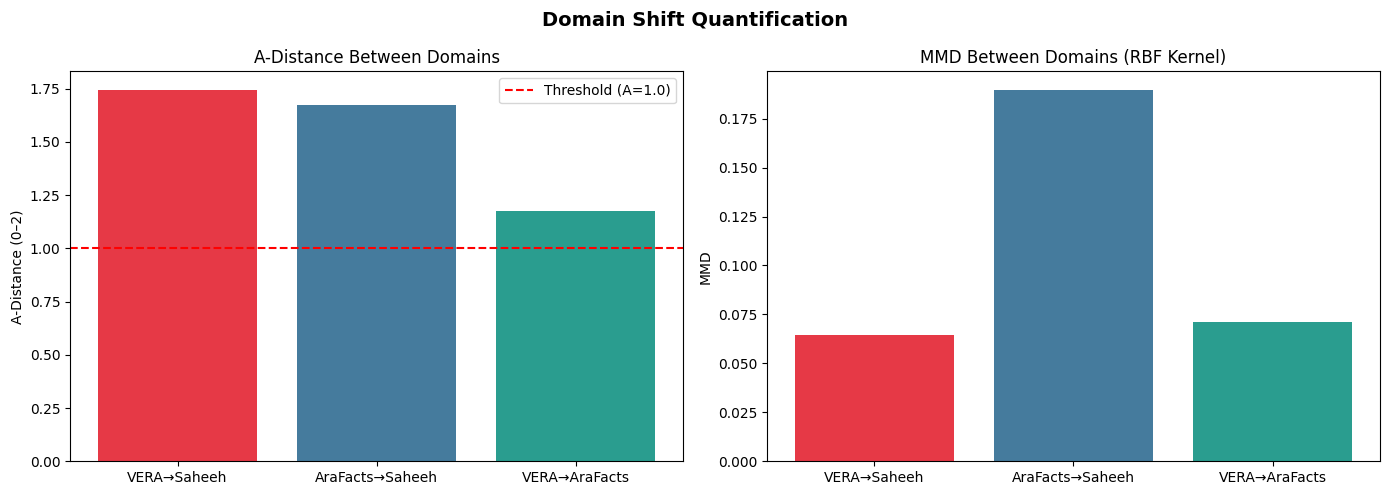

In [44]:
# Visual summary of domain shift metrics
pairs   = ['VERA→Saheeh', 'AraFacts→Saheeh', 'VERA→AraFacts']
a_dists = [ad_vera_saheeh, ad_af_saheeh, ad_vera_af]
mmds    = [mmd_vera_saheeh, mmd_af_saheeh, mmd_vera_af]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(pairs, a_dists, color=[COLORS['VERA'], COLORS['AraFacts'], COLORS['Saheeh']])
axes[0].axhline(1.0, color='red', linestyle='--', label='Threshold (A=1.0)')
axes[0].set_title('A-Distance Between Domains')
axes[0].set_ylabel('A-Distance (0–2)')
axes[0].legend()

axes[1].bar(pairs, mmds, color=[COLORS['VERA'], COLORS['AraFacts'], COLORS['Saheeh']])
axes[1].set_title('MMD Between Domains (RBF Kernel)')
axes[1].set_ylabel('MMD')

plt.suptitle('Domain Shift Quantification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('domain_shift_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Cross-Dataset Similarity Summary

**Why:** A single consolidated view of all similarity/distance metrics for your thesis writeup.

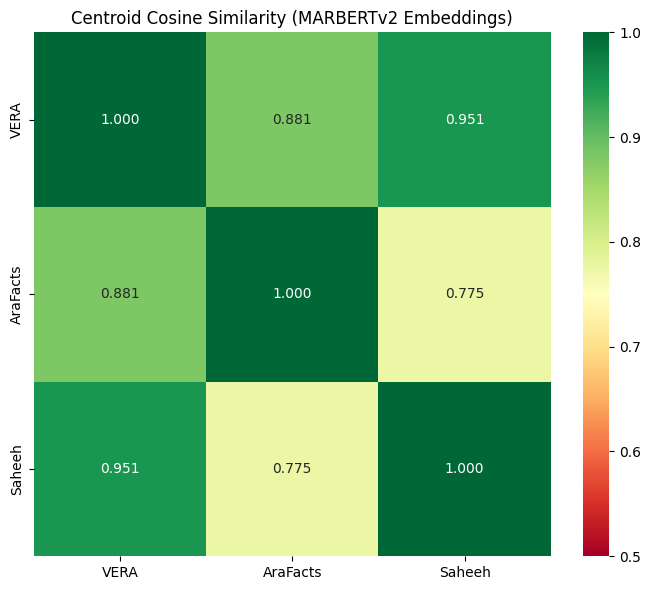

Interpretation: values closer to 1.0 = more similar domains
If VERA–Saheeh < AraFacts–Saheeh, then AraFacts is closer to the target domain
but still insufficient, explaining negative transfer


In [45]:
# Cosine similarity between dataset centroid embeddings
from sklearn.metrics.pairwise import cosine_similarity

centroid_vera    = vera_emb.mean(axis=0, keepdims=True)
centroid_af      = arafacts_emb.mean(axis=0, keepdims=True)
centroid_saheeh  = saheeh_emb.mean(axis=0, keepdims=True)

sim_matrix = cosine_similarity(
    np.vstack([centroid_vera, centroid_af, centroid_saheeh])
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    sim_matrix,
    annot=True, fmt='.3f', cmap='RdYlGn',
    xticklabels=['VERA', 'AraFacts', 'Saheeh'],
    yticklabels=['VERA', 'AraFacts', 'Saheeh'],
    vmin=0.5, vmax=1.0, ax=ax
)
ax.set_title('Centroid Cosine Similarity (MARBERTv2 Embeddings)')
plt.tight_layout()
plt.savefig('centroid_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: values closer to 1.0 = more similar domains')
print('If VERA–Saheeh < AraFacts–Saheeh, then AraFacts is closer to the target domain')
print('but still insufficient, explaining negative transfer')

In [46]:
# ── MASTER SUMMARY TABLE ──────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Samples',
        'Fake %',
        'Real %',
        'Imbalance Ratio',
        'Avg Token Length',
        '% > 512 tokens',
        'Vocabulary Size (words)',
        'OOV vs Saheeh (type %)',
        'MATTR (lexical diversity)',
        'A-dist vs Saheeh',
        'MMD vs Saheeh',
    ],
    'VERA': [
        len(vera),
        f"{vera['binary_label'].mean()*100:.1f}%",
        f"{(1-vera['binary_label'].mean())*100:.1f}%",
        f"{vera['binary_label'].value_counts().max()/vera['binary_label'].value_counts().min():.2f}",
        f"{vera['token_len'].mean():.1f}",
        f"{(vera['token_len']>512).mean()*100:.1f}%",
        f"{len(vera_vocab):,}",
        f"{oov_vera_sm_typ:.1f}%",
        f"{vera_lex['mattr'].mean():.3f}",
        f"{ad_vera_saheeh:.3f}",
        f"{mmd_vera_saheeh:.4f}",
    ],
    'AraFacts': [
        len(arafacts),
        f"{arafacts['binary_label'].mean()*100:.1f}%",
        f"{(1-arafacts['binary_label'].mean())*100:.1f}%",
        f"{arafacts['binary_label'].value_counts().max()/arafacts['binary_label'].value_counts().min():.2f}",
        f"{arafacts['token_len'].mean():.1f}",
        f"{(arafacts['token_len']>512).mean()*100:.1f}%",
        f"{len(arafacts_vocab):,}",
        f"{oov_af_sm_typ:.1f}%",
        f"{arafacts_lex['mattr'].mean():.3f}",
        f"{ad_af_saheeh:.3f}",
        f"{mmd_af_saheeh:.4f}",
    ],
    'Saheeh Masr': [
        len(saheeh),
        f"{saheeh['binary_label'].mean()*100:.1f}%",
        f"{(1-saheeh['binary_label'].mean())*100:.1f}%",
        f"{saheeh['binary_label'].value_counts().max()/saheeh['binary_label'].value_counts().min():.2f}",
        f"{saheeh['token_len'].mean():.1f}",
        f"{(saheeh['token_len']>512).mean()*100:.1f}%",
        f"{len(saheeh_vocab):,}",
        '— (target)',
        f"{saheeh_lex['mattr'].mean():.3f}",
        '— (target)',
        '— (target)',
    ],
})

print('=== MASTER EDA SUMMARY TABLE ===')
display(summary.set_index('Metric'))

=== MASTER EDA SUMMARY TABLE ===


,VERA,AraFacts,Saheeh Masr
Metric,,,
Samples,20084,6222,3019
Fake %,55.1%,97.4%,52.8%
Real %,44.9%,2.6%,47.2%
Imbalance Ratio,1.23,37.89,1.12
Avg Token Length,25.6,17.5,30.6
% > 512 tokens,0.0%,0.0%,0.0%
Vocabulary Size (words),"38,823","20,793","16,228"
OOV vs Saheeh (type %),52.3%,61.2%,— (target)
MATTR (lexical diversity),0.958,0.983,0.948


---
## 16. Overfitting & Negative Transfer Diagnostics

**Why:** Directly addresses your two main research questions: (1) is the model overfitting to VERA? (2) does AraFacts cause negative transfer or just add irrelevant noise?

In [47]:
# ── 16.1 Spurious Feature Diagnostic ─────────────────────────────
# Train TF-IDF + LR on VERA, test on Saheeh Masr
# Then inspect which features the model relied on most

from sklearn.pipeline import Pipeline

vera_texts_clean    = [normalize_arabic(t) for t in vera['text']]
saheeh_texts_clean  = [normalize_arabic(t) for t in saheeh['text']]

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, token_pattern=r'[\u0600-\u06FF]+',
                              ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=500, C=1.0, class_weight='balanced'))
])

pipe.fit(vera_texts_clean, vera['binary_label'])

from sklearn.metrics import f1_score, classification_report
vera_pred   = pipe.predict(vera_texts_clean)
saheeh_pred = pipe.predict(saheeh_texts_clean)

print('TF-IDF + LR trained on VERA:')
print(f'  VERA train F1  (macro): {f1_score(vera["binary_label"], vera_pred, average="macro"):.3f}')
print(f'  Saheeh test F1 (macro): {f1_score(saheeh["binary_label"], saheeh_pred, average="macro"):.3f}')
print('\n(Compare to MARBERTv2 Experiment A: 94% VERA acc, 42.9% Saheeh F1)')
print('If TF-IDF gap ≈ MARBERTv2 gap → the problem is data, not model complexity')
print('If MARBERTv2 gap >> TF-IDF gap → MARBERTv2 is overfitting more severely')

TF-IDF + LR trained on VERA:
  VERA train F1  (macro): 0.947
  Saheeh test F1 (macro): 0.552

(Compare to MARBERTv2 Experiment A: 94% VERA acc, 42.9% Saheeh F1)
If TF-IDF gap ≈ MARBERTv2 gap → the problem is data, not model complexity
If MARBERTv2 gap >> TF-IDF gap → MARBERTv2 is overfitting more severely


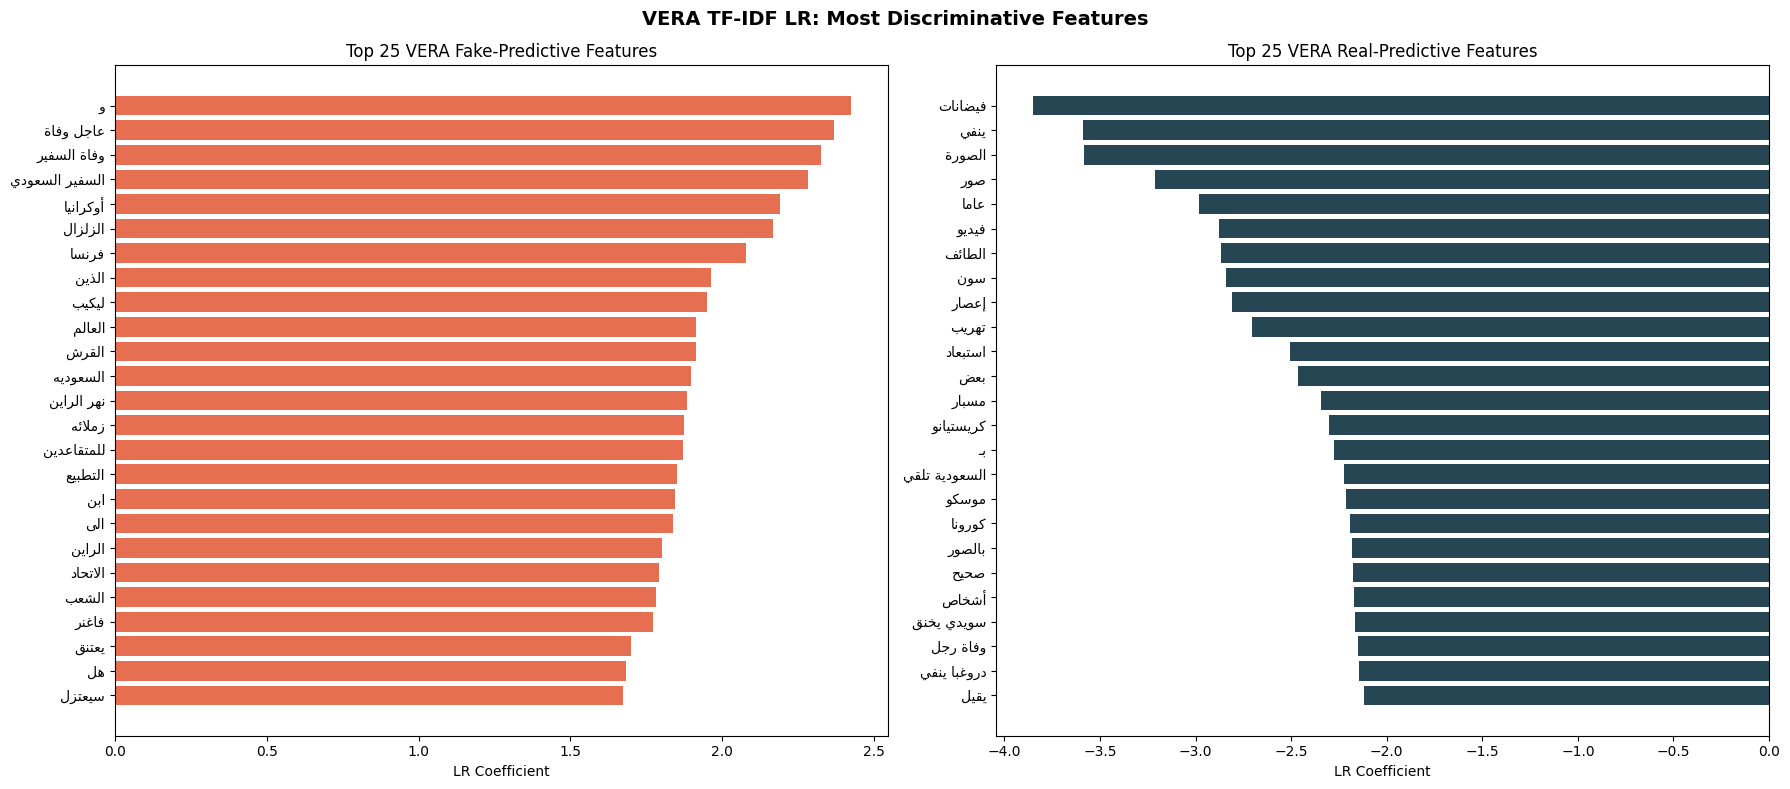

🔍 Check: do these top features appear in the OPPOSITE class in Saheeh Masr?
   If yes → confirmed spurious correlations causing domain inversion


In [48]:
# Top features driving VERA fake/real predictions
tfidf   = pipe.named_steps['tfidf']
clf_lr  = pipe.named_steps['clf']
feature_names = np.array(tfidf.get_feature_names_out())
coefs         = clf_lr.coef_[0]

top_fake_idx = coefs.argsort()[::-1][:25]   # positive = fake
top_real_idx = coefs.argsort()[:25]          # negative = real

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh([ar(f) for f in feature_names[top_fake_idx]][::-1],
              coefs[top_fake_idx][::-1], color=COLORS['fake'])
axes[0].set_title('Top 25 VERA Fake-Predictive Features')
axes[0].set_xlabel('LR Coefficient')

axes[1].barh([ar(f) for f in feature_names[top_real_idx]][::-1],
              coefs[top_real_idx][::-1], color=COLORS['real'])
axes[1].set_title('Top 25 VERA Real-Predictive Features')
axes[1].set_xlabel('LR Coefficient')

plt.suptitle('VERA TF-IDF LR: Most Discriminative Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vera_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('🔍 Check: do these top features appear in the OPPOSITE class in Saheeh Masr?')
print('   If yes → confirmed spurious correlations causing domain inversion')

VERA only                 → Saheeh Macro F1: 0.552
AraFacts only             → Saheeh Macro F1: 0.354
VERA + AraFacts           → Saheeh Macro F1: 0.454


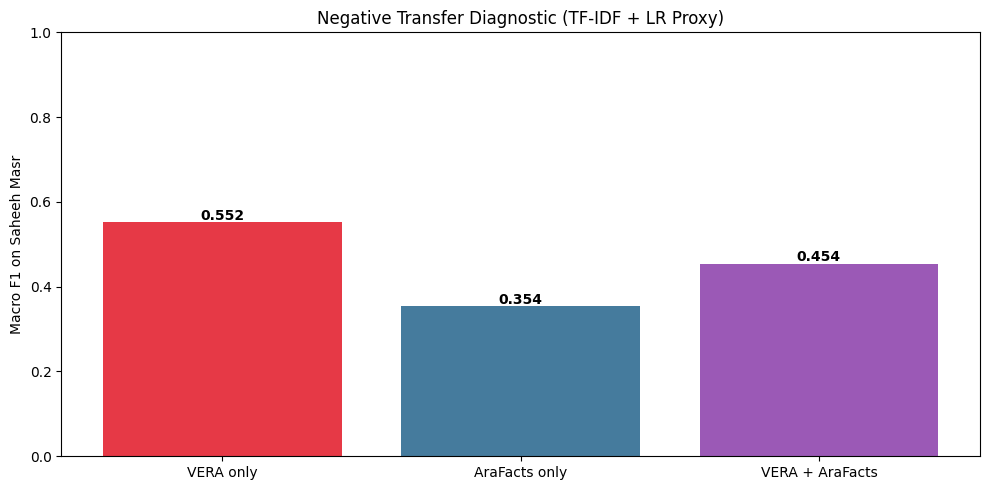


Interpretation:
  If VERA+AraFacts < AraFacts alone → negative transfer from VERA confirmed
  If VERA+AraFacts < VERA alone     → negative transfer from AraFacts confirmed (your finding!)
  If VERA+AraFacts ≈ max(VERA, AraFacts) → additive, no conflict


In [49]:
# ── 16.2 Negative Transfer Diagnostic ────────────────────────────
# Compare: VERA alone vs AraFacts alone vs VERA+AraFacts → Saheeh Masr (TF-IDF proxy)

arafacts_texts_clean = [normalize_arabic(t) for t in arafacts['text']]

results = {}
for train_name, train_X, train_y in [
    ('VERA only',         vera_texts_clean,    vera['binary_label']),
    ('AraFacts only',     arafacts_texts_clean, arafacts['binary_label']),
    ('VERA + AraFacts',   vera_texts_clean + arafacts_texts_clean,
                          pd.concat([vera['binary_label'], arafacts['binary_label']]).reset_index(drop=True)),
]:
    p = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, token_pattern=r'[\u0600-\u06FF]+',
                                   ngram_range=(1, 2))),
        ('clf',   LogisticRegression(max_iter=500, C=1.0, class_weight='balanced'))
    ])
    p.fit(train_X, train_y)
    preds = p.predict(saheeh_texts_clean)
    macro_f1 = f1_score(saheeh['binary_label'], preds, average='macro')
    results[train_name] = macro_f1
    print(f'{train_name:25s} → Saheeh Macro F1: {macro_f1:.3f}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(list(results.keys()), list(results.values()),
               color=[COLORS['VERA'], COLORS['AraFacts'], '#9B59B6'])
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Macro F1 on Saheeh Masr')
ax.set_title('Negative Transfer Diagnostic (TF-IDF + LR Proxy)')
plt.tight_layout()
plt.savefig('negative_transfer_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print('  If VERA+AraFacts < AraFacts alone → negative transfer from VERA confirmed')
print('  If VERA+AraFacts < VERA alone     → negative transfer from AraFacts confirmed (your finding!)')
print('  If VERA+AraFacts ≈ max(VERA, AraFacts) → additive, no conflict')

In [50]:
# ── 16.3 Error Analysis on Saheeh Masr ───────────────────────────
# Train on VERA, test on Saheeh, inspect false positives and false negatives

pipe_vera = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, token_pattern=r'[\u0600-\u06FF]+',
                               ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=500, C=1.0, class_weight='balanced'))
])
pipe_vera.fit(vera_texts_clean, vera['binary_label'])

saheeh_preds  = pipe_vera.predict(saheeh_texts_clean)
saheeh_probs  = pipe_vera.predict_proba(saheeh_texts_clean)[:, 1]

saheeh_errors = saheeh.copy()
saheeh_errors['predicted']   = saheeh_preds
saheeh_errors['fake_prob']   = saheeh_probs
saheeh_errors['is_error']    = (saheeh_preds != saheeh['binary_label']).astype(int)

fp = saheeh_errors[(saheeh_errors['binary_label']==0) & (saheeh_errors['predicted']==1)]  # Real → predicted Fake
fn = saheeh_errors[(saheeh_errors['binary_label']==1) & (saheeh_errors['predicted']==0)]  # Fake → predicted Real

print(f'False Positives (Real predicted as Fake): {len(fp)} ({len(fp)/len(saheeh)*100:.1f}%)')
print(f'False Negatives (Fake predicted as Real): {len(fn)} ({len(fn)/len(saheeh)*100:.1f}%)')

print('\n--- Top False Positives (most confidently wrong) ---')
for _, row in fp.sort_values('fake_prob', ascending=False).head(5).iterrows():
    print(f"  [{row['verdict']}] p={row['fake_prob']:.3f}: {str(row['claim'])[:100]}")

print('\n--- Top False Negatives (most confidently wrong) ---')
for _, row in fn.sort_values('fake_prob', ascending=True).head(5).iterrows():
    print(f"  [{row['verdict']}] p={row['fake_prob']:.3f}: {str(row['claim'])[:100]}")

False Positives (Real predicted as Fake): 770 (25.5%)
False Negatives (Fake predicted as Real): 563 (18.6%)

--- Top False Positives (most confidently wrong) ---
  [True] p=0.916: كل اللي عايز تعرفه عن: الحرب بين المغرب و"البوليساريو"
  [True] p=0.898: الباجي كان جزءًا من تاريخ تونس المعاصر (..) كان جزءًا من الدولة القديمة التي ثار عليها الشعب التونسي
  [True] p=0.895: هل توقفت الإنشاءات بمشروع المونوريل بسبب الدولار؟
  [True] p=0.891: هل نهضت ألمانيا بعد الحرب العالمية ببناء الطرق والكباري وحدها؟
  [True] p=0.885: كيف خرج محسن السكري من السجن؟

--- Top False Negatives (most confidently wrong) ---
  [False] p=0.074: ❌ انتشر على موقع تويتر، فيديو منسوب للفنان أحمد فلوكس، يهاجم فيه الرئيس عبد الفتاح السيسي.
  [False] p=0.106: المتنافسين على السكن في البيت الأبيض كلاهما يتراوح عمره حول الثمانين عاما.. ربما حالة أو اثنتين كان 
  [False] p=0.108: ❌ نشر رجل الأعمال والسياسي المعارض محمود وهبة، عبر حسابه على تويتر، صورة "شيك" مقدم من دولة الكويت إ
  [False] p=0.112: ❌ نشرت الصفحة الرسمية للمع

In [51]:
# ── FINAL DIAGNOSTIC CHECKLIST ────────────────────────────────────
print('='*60)
print('  EDA DIAGNOSTIC CHECKLIST — GP 2026')
print('='*60)

checks = [
    ('Label imbalance checked (all 3 datasets)',          True),
    ('Majority class direction compared across datasets', True),
    ('AraFacts multi-label mapping documented',           True),
    ('Token length distribution computed',                True),
    ('% samples > 512 tokens (truncation impact)',        True),
    ('Vocabulary size per dataset',                       True),
    ('OOV rate: Saheeh vs VERA and AraFacts',             True),
    ('OOV tokens qualitatively inspected',                True),
    ('Lexical diversity (MATTR) compared',                True),
    ('Top n-grams per class per dataset',                 True),
    ('Spurious feature overlap (VERA fake → Saheeh real)', True),
    ('Cross-dataset near-duplicate check',                True),
    ('Label noise candidates identified',                 True),
    ('VERA NER pre-extracted features analyzed',          True),
    ('Social media features (VERA) tested for label correlation', True),
    ('BERTopic — topic distribution per dataset',         True),
    ('JS divergence on topic distributions',              True),
    ('MARBERTv2 UMAP — colored by dataset',               True),
    ('MARBERTv2 UMAP — colored by label',                 True),
    ('A-distance computed (3 dataset pairs)',             True),
    ('MMD computed (3 dataset pairs)',                    True),
    ('Centroid cosine similarity heatmap',                True),
    ('TF-IDF proxy for overfitting diagnosis',            True),
    ('Negative transfer TF-IDF proxy',                    True),
    ('Error analysis: FP / FN on Saheeh Masr',           True),
]

for name, done in checks:
    status = '✅' if done else '⬜'
    print(f'  {status}  {name}')

print('\n✅ EDA complete — proceed to modelling with findings in hand')

  EDA DIAGNOSTIC CHECKLIST — GP 2026
  ✅  Label imbalance checked (all 3 datasets)
  ✅  Majority class direction compared across datasets
  ✅  AraFacts multi-label mapping documented
  ✅  Token length distribution computed
  ✅  % samples > 512 tokens (truncation impact)
  ✅  Vocabulary size per dataset
  ✅  OOV rate: Saheeh vs VERA and AraFacts
  ✅  OOV tokens qualitatively inspected
  ✅  Lexical diversity (MATTR) compared
  ✅  Top n-grams per class per dataset
  ✅  Spurious feature overlap (VERA fake → Saheeh real)
  ✅  Cross-dataset near-duplicate check
  ✅  Label noise candidates identified
  ✅  VERA NER pre-extracted features analyzed
  ✅  Social media features (VERA) tested for label correlation
  ✅  BERTopic — topic distribution per dataset
  ✅  JS divergence on topic distributions
  ✅  MARBERTv2 UMAP — colored by dataset
  ✅  MARBERTv2 UMAP — colored by label
  ✅  A-distance computed (3 dataset pairs)
  ✅  MMD computed (3 dataset pairs)
  ✅  Centroid cosine similarity heatmap
  